## Introduction

Many contemporary datasets include links between geographic locations and natural language texts, commonly referred to as geotext data. The rise of social media platforms has significantly contributed to the growth of this data type, as users often share content tagged with location information. Such data offers valuable insights into human mobility patterns as well as public perceptions and opinions about specific places. These insights can inform urban planning efforts, contributing to more effective infrastructure design, equitable resource distribution, and overall improvements in city development (Hu, 2018; Carvalho, Ferreira & Dias, 2021; Zhang et al., 2021).

Several studies have explored mobility analysis using various data sources. For instance, Chen et al. (2024) examined individual socioeconomic status through mobile phone mobility data, incorporating social network information from social media. Terroso-Saenz, Flores, and Muñoz (2022) investigated transportation-related mobility in a nationwide mobile phone-based study in Spain. Zhong, Morphet, and Yoshida (2023) analyzed mobility patterns in London during the COVID-19 pandemic using Twitter data. Similarly, Martín et al. (2020) assessed population mobility in the aftermath of Hurricane Maria in Puerto Rico through Twitter-based mobility data.

While geo-text data offers substantial research potential, it presents notable challenges due to the unstructured nature of textual content and the spatial ambiguity of certain locations. Nevertheless, its ability to combine semantic and geographic dimensions makes it a valuable resource for mobility research (Hu, 2018). This study contributes by outlining techniques for analyzing mobility and textual data, using mobility datasets from Gowalla in Cambridge and amenity review texts from Calgary, Canada, to inform future research.

## Mobility Patterns Analysis in Cambridge

Location is a fundamental spatial attribute and plays a crucial role in understanding daily human movement. Human mobility data offers detailed insights into how individuals interact with each other and their environment, as well as how they use urban spaces and engage in daily activities (Gao & Liu, 2015; Zhang et al., 2021)


In this first part of the analysis, the author uses the 2010 Cambridge Individual Mobility Dataset from Gowalla to analyze individual mobility patterns and characterize check-in locations. The study also proposes a new amenity, such as a community park, based on insights derived from the Gowalla dataset and OpenStreetMap data.


### Mobility Patterns: Question 1 (Visualise individual check-in locations)

In [ ]:
!pip install geoviews
!pip install movingpandas
!pip install hvplot
!pip install osmnx
!pip install contextily
!pip install matplotlib-scalebar
import torch
import pandas as pd
import numpy as np
import os
import movingpandas as mpd
import hvplot.pandas
import geopandas as gpd
import geoviews as gv
from shapely.geometry import LineString
import cartopy.crs as ccrs
from geoviews import tile_sources as gvts
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
import osmnx as ox # this line imports osmnx
import networkx as nx # this line imports networkx
import matplotlib.cm as cm
import matplotlib.colors as colors
import contextily as ctx
from shapely.geometry import LineString, MultiLineString
import pyproj
from sklearn.cluster import DBSCAN
from datetime import timedelta
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from shapely.geometry import box
import matplotlib.colors as mcolors
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import  TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import sent_tokenize, word_tokenize, pos_tag
import matplotlib.pyplot as plt
from shapely.geometry import Point
import matplotlib.patheffects as path_effects
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.lines as mlines


print("CUDA Available:", torch.cuda.is_available())

from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/My Drive/GEOG0051/'

CUDA Available: False
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This study will focus on two specific user IDs: 75027 and 102829. Upon examining the dataset for these individuals, it was found that the data is incomplete as the hourly records are missing for some of the days, and there are day period from April 17 to May 27, 2010 that are not available. As a result, this research will provide a spatial overview of the areas visited by these users during the available time frame. The missing data may be due to anonymization measures, which limit the ability to infer detailed user behavior.

In [ ]:
cambridge = os.path.join(base_path, 'Cambridge_gowalla.csv')
cambridge_df = pd.read_csv(cambridge)
#cambridge_df.head(10)
#cambridge_df.info()
cambridge_df['date_time'] = pd.to_datetime(cambridge_df['date'] + ' ' + cambridge_df['Time'],dayfirst=True)

#filter the dataset on users with User IDs [75027] and [102829]
filtered_df = cambridge_df[cambridge_df['User_ID'].isin([75027, 102829])]
# Group by user
trajectories = {}

for user_id, user_df in filtered_df.groupby('User_ID'):
    user_df_sorted = user_df.sort_values('date_time')
    trajectories[user_id] = mpd.Trajectory(user_df_sorted, user_id, t='date_time', x='lon', y='lat')

#print(trajectories[102829])
#print(trajectories[102829].df.head(100))
#print(trajectories[102829].df.columns)

#Code source: (OpenAI, 2025e; OpenAI, 2025j)

This section presents a visualization of the mobility trajectories of two users (IDs: 75027 and 102829). Dates with only a single recorded coordinate were excluded, and only days with multiple coordinates were used to construct the trajectory plots. Each figure combines all relevant daily trajectories for the respective users. In the plots, orange circles indicate the first recorded coordinate of each day, red triangles represent the last, and green squares mark instances where a day ends and the next begins at the same location. Furthermore, symbol size reflects the frequency of coordinate occurrences in the dataset.

The green square markers may indicate users’ home locations, particularly if they appear consistently across multiple days. Alternatively, these patterns could reflect data limitations, such as intermittent recording that happens to resume at the same location on different days. Nonetheless, the recurrence of green squares suggests a regular presence of both users at these locations between April 17 and May 27, 2010.

The largest green square for user 75027 is located on Rustat Road in the Coleridge ward, near Cambridge train station. Two additional green squares appear in the Cambridge Retail Park area, potentially indicating that the user works or shops there. Moreover, the largest green square for user 102829 is located on Madingley Road, near the West Cambridge campus of the University of Cambridge. Additionally, two other green squares appear in close proximity, suggesting that this user may work or regularly engage in activities within this area. High activity levels are also observed at the Co-op Food on Grantchester Street in Newnham and at Cambridge Train Station.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
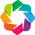

:Overlay
   .WMTS.I        :WMTS   [Longitude,Latitude]
   .Path.I        :Path   [Longitude,Latitude]
   .Path.II       :Path   [Longitude,Latitude]
   .Path.III      :Path   [Longitude,Latitude]
   .Path.IV       :Path   [Longitude,Latitude]
   .Path.V        :Path   [Longitude,Latitude]
   .Path.VI       :Path   [Longitude,Latitude]
   .Path.VII      :Path   [Longitude,Latitude]
   .Path.VIII     :Path   [Longitude,Latitude]
   .Path.IX       :Path   [Longitude,Latitude]
   .Path.X        :Path   [Longitude,Latitude]
   .Path.XI       :Path   [Longitude,Latitude]
   .Path.XII      :Path   [Longitude,Latitude]
   .Path.XIII     :Path   [Longitude,Latitude]
   .Path.XIV      :Path   [Longitude,Latitude]
   .Path.XV       :Path   [Longitude,Latitude]
   .Path.XVI      :Path   [Longitude,Latitude]
   .Points.I      :Points   [Longitude,Latitude]
   .Points.II     :Points   [Longitude,Latitude]
   .Points.III    :Points   [Longitude,Latitude]
   .Points.IV     :Points   [Longitude,Latitude]
   .Points.V      :Points   [Longitude,Latitude]
   .Points.VI     :Points   [Longitude,Latitude]
   .Points.VII    :Points   [Longitude,Latitude]
   .Points.VIII   :Points   [Longitude,Latitude]
   .Points.IX     :Points   [Longitude,Latitude]
   .Points.X      :Points   [Longitude,Latitude]
   .Points.XI     :Points   [Longitude,Latitude]
   .Points.XII    :Points   [Longitude,Latitude]
   .Points.XIII   :Points   [Longitude,Latitude]
   .Points.XIV    :Points   [Longitude,Latitude]
   .Points.XV     :Points   [Longitude,Latitude]
   .Points.XVI    :Points   [Longitude,Latitude]
   .Points.XVII   :Points   [Longitude,Latitude]
   .Points.XVIII  :Points   [Longitude,Latitude]
   .Points.XIX    :Points   [Longitude,Latitude]
   .Points.XX     :Points   [Longitude,Latitude]
   .Points.XXI    :Points   [Longitude,Latitude]
   .Points.XXII   :Points   [Longitude,Latitude]
   .Points.XXIII  :Points   [Longitude,Latitude]
   .Points.XXIV   :Points   [Longitude,Latitude]
   .Points.XXV    :Points   [Longitude,Latitude]
   .Points.XXVI   :Points   [Longitude,Latitude]
   .Points.XXVII  :Points   [Longitude,Latitude]
   .Points.XXVIII :Points   [Longitude,Latitude]
   .Points.XXIX   :Points   [Longitude,Latitude]
   .Points.XXX    :Points   [Longitude,Latitude]
   .Points.XXXI   :Points   [Longitude,Latitude]
   .Points.XXXII  :Points   [Longitude,Latitude]

In [ ]:
gv.extension('bokeh')
user_df = trajectories[75027].df.reset_index()
user_df['lon'] = user_df['geometry'].x #Extracts the longitude from the geometry column
user_df['lat'] = user_df['geometry'].y #Extracts the latitude from the geometry column
user_df['date'] = user_df['date_time'].dt.date #Extracts the date part only and exclude the time

day_groups = user_df.groupby('date') #Groups the data by date
crs = ccrs.PlateCarree() #sets the crs to platecarree for maps plotting

#initialize empty list
trajectory_lines = []
start_points = []
end_arrows = []
overlap_points = []

start_counter = Counter() #track how many times the coordinates are used as start points
end_counter = Counter() #track how many times the coordinates are used as start points

for date, df_day in day_groups:
    if len(df_day) > 1: #skips day where there is only one coordinate
        df_day_sorted = df_day.sort_values('date_time') #sort by time
        start = df_day_sorted.iloc[0] #sort the data by the earliest coordinate
        end = df_day_sorted.iloc[-1] #sort the data by the the latest coordinate
        start_coord = (start['lon'], start['lat']) #extract the very first coordinate of the day
        end_coord = (end['lon'], end['lat']) #extract the last coordinate of the day
        start_counter[start_coord] += 1 #Updates counters
        end_counter[end_coord] += 1 #Updates counters

overlap_coords = set(start_counter.keys()).intersection(end_counter.keys()) #find the intersection of the coordinates that appear in the start of any day and the last of any day

for date, df_day in day_groups:
    if len(df_day) > 1: #skips day where there is only one coordinate
        df_day_sorted = df_day.sort_values('date_time') #sort by time

        line = LineString(zip(df_day_sorted['lon'], df_day_sorted['lat'])) #combines the longitude and latitude pairs into a line string
        gdf_line = gpd.GeoDataFrame(geometry=[line], crs="EPSG:4326") #transform the line into geodataframe
        traj_plot = gdf_line.hvplot(geo=True, line_width=2, color='blue') #plot the line on a map
        trajectory_lines.append(traj_plot)

        start = df_day_sorted.iloc[0] #sort the data by the earliest coordinate
        end = df_day_sorted.iloc[-1] #sort the data by the the latest coordinate
        start_coord = (start['lon'], start['lat']) #extract the very first coordinate of the day
        end_coord = (end['lon'], end['lat']) #extract the last coordinate of the day

        # Plot
        if start_coord in overlap_coords: #for coordinates that appear in both start and end coordinate of a day
            size = 6 + 2 * (start_counter[start_coord] + end_counter[start_coord]) #Make the size bigger if it frequently appeared
            overlap_geom = gv.Points([start_coord], crs=crs)
            overlap_points.append(overlap_geom.opts(color='green', size=size, marker='square'))
        else:
            size = 6 + 2 * start_counter[start_coord] #Make the size bigger if it frequently appeared
            start_geom = gv.Points([start_coord], crs=crs)
            start_points.append(start_geom.opts(color='orange', size=size, marker='circle'))

        if end_coord in overlap_coords: #for coordinates that appear in both start and end coordinate of a day
            size = 6 + 2 * (start_counter[end_coord] + end_counter[end_coord]) #Make the size bigger if it frequently appeared
            overlap_geom = gv.Points([end_coord], crs=crs)
            overlap_points.append(overlap_geom.opts(color='green', size=size, marker='square'))
        else:
            size = 6 + 2 * end_counter[end_coord] #Make the size bigger if it frequently appeared
            end_geom = gv.Points([end_coord], crs=crs)
            end_arrows.append(end_geom.opts(color='red', size=size, marker='triangle'))

# Create map
tiles = gvts.OSM.opts(width=800, height=700) #loads OpenStreetMap tiles
overlay = gv.Overlay(trajectory_lines + start_points + end_arrows + overlap_points) #add all the overlay elements that have been set before
final_plot = tiles * overlay

final_plot

#Code source: (OpenAI, 2025f)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
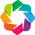

:Overlay
   .WMTS.I         :WMTS   [Longitude,Latitude]
   .Path.I         :Path   [Longitude,Latitude]
   .Path.II        :Path   [Longitude,Latitude]
   .Path.III       :Path   [Longitude,Latitude]
   .Path.IV        :Path   [Longitude,Latitude]
   .Path.V         :Path   [Longitude,Latitude]
   .Path.VI        :Path   [Longitude,Latitude]
   .Path.VII       :Path   [Longitude,Latitude]
   .Path.VIII      :Path   [Longitude,Latitude]
   .Path.IX        :Path   [Longitude,Latitude]
   .Path.X         :Path   [Longitude,Latitude]
   .Path.XI        :Path   [Longitude,Latitude]
   .Path.XII       :Path   [Longitude,Latitude]
   .Path.XIII      :Path   [Longitude,Latitude]
   .Path.XIV       :Path   [Longitude,Latitude]
   .Path.XV        :Path   [Longitude,Latitude]
   .Path.XVI       :Path   [Longitude,Latitude]
   .Path.XVII      :Path   [Longitude,Latitude]
   .Path.XVIII     :Path   [Longitude,Latitude]
   .Path.XIX       :Path   [Longitude,Latitude]
   .Path.XX        :Path   [Longitude,Latitude]
   .Path.XXI       :Path   [Longitude,Latitude]
   .Points.I       :Points   [Longitude,Latitude]
   .Points.II      :Points   [Longitude,Latitude]
   .Points.III     :Points   [Longitude,Latitude]
   .Points.IV      :Points   [Longitude,Latitude]
   .Points.V       :Points   [Longitude,Latitude]
   .Points.VI      :Points   [Longitude,Latitude]
   .Points.VII     :Points   [Longitude,Latitude]
   .Points.VIII    :Points   [Longitude,Latitude]
   .Points.IX      :Points   [Longitude,Latitude]
   .Points.X       :Points   [Longitude,Latitude]
   .Points.XI      :Points   [Longitude,Latitude]
   .Points.XII     :Points   [Longitude,Latitude]
   .Points.XIII    :Points   [Longitude,Latitude]
   .Points.XIV     :Points   [Longitude,Latitude]
   .Points.XV      :Points   [Longitude,Latitude]
   .Points.XVI     :Points   [Longitude,Latitude]
   .Points.XVII    :Points   [Longitude,Latitude]
   .Points.XVIII   :Points   [Longitude,Latitude]
   .Points.XIX     :Points   [Longitude,Latitude]
   .Points.XX      :Points   [Longitude,Latitude]
   .Points.XXI     :Points   [Longitude,Latitude]
   .Points.XXII    :Points   [Longitude,Latitude]
   .Points.XXIII   :Points   [Longitude,Latitude]
   .Points.XXIV    :Points   [Longitude,Latitude]
   .Points.XXV     :Points   [Longitude,Latitude]
   .Points.XXVI    :Points   [Longitude,Latitude]
   .Points.XXVII   :Points   [Longitude,Latitude]
   .Points.XXVIII  :Points   [Longitude,Latitude]
   .Points.XXIX    :Points   [Longitude,Latitude]
   .Points.XXX     :Points   [Longitude,Latitude]
   .Points.XXXI    :Points   [Longitude,Latitude]
   .Points.XXXII   :Points   [Longitude,Latitude]
   .Points.XXXIII  :Points   [Longitude,Latitude]
   .Points.XXXIV   :Points   [Longitude,Latitude]
   .Points.XXXV    :Points   [Longitude,Latitude]
   .Points.XXXVI   :Points   [Longitude,Latitude]
   .Points.XXXVII  :Points   [Longitude,Latitude]
   .Points.XXXVIII :Points   [Longitude,Latitude]
   .Points.XXXIX   :Points   [Longitude,Latitude]
   .Points.XL      :Points   [Longitude,Latitude]
   .Points.XLI     :Points   [Longitude,Latitude]
   .Points.XLII    :Points   [Longitude,Latitude]

In [ ]:
gv.extension('bokeh')
user_df = trajectories[102829].df.reset_index()
user_df['lon'] = user_df['geometry'].x #Extracts the longitude from the geometry column
user_df['lat'] = user_df['geometry'].y #Extracts the latitude from the geometry column
user_df['date'] = user_df['date_time'].dt.date #Extracts the date part only and exclude the time

day_groups = user_df.groupby('date') #Groups the data by date
crs = ccrs.PlateCarree() #sets the crs to platecarree for maps plotting

#initialize empty list
trajectory_lines = []
start_points = []
end_arrows = []
overlap_points = []

start_counter = Counter() #track how many times the coordinates are used as start points
end_counter = Counter() #track how many times the coordinates are used as start points

for date, df_day in day_groups:
    if len(df_day) > 1: #skips day where there is only one coordinate
        df_day_sorted = df_day.sort_values('date_time') #sort by time
        start = df_day_sorted.iloc[0] #sort the data by the earliest coordinate
        end = df_day_sorted.iloc[-1] #sort the data by the the latest coordinate
        start_coord = (start['lon'], start['lat']) #extract the very first coordinate of the day
        end_coord = (end['lon'], end['lat']) #extract the last coordinate of the day
        start_counter[start_coord] += 1 #Updates counters
        end_counter[end_coord] += 1 #Updates counters

overlap_coords = set(start_counter.keys()).intersection(end_counter.keys()) #find the intersection of the coordinates that appear in the start of any day and the last of any day

for date, df_day in day_groups:
    if len(df_day) > 1: #skips day where there is only one coordinate
        df_day_sorted = df_day.sort_values('date_time') #sort by time

        line = LineString(zip(df_day_sorted['lon'], df_day_sorted['lat'])) #combines the longitude and latitude pairs into a line string
        gdf_line = gpd.GeoDataFrame(geometry=[line], crs="EPSG:4326") #transform the line into geodataframe
        traj_plot = gdf_line.hvplot(geo=True, line_width=2, color='blue') #plot the line on a map
        trajectory_lines.append(traj_plot)

        start = df_day_sorted.iloc[0] #sort the data by the earliest coordinate
        end = df_day_sorted.iloc[-1] #sort the data by the the latest coordinate
        start_coord = (start['lon'], start['lat']) #extract the very first coordinate of the day
        end_coord = (end['lon'], end['lat']) #extract the last coordinate of the day

        # Plot
        if start_coord in overlap_coords: #for coordinates that appear in both start and end coordinate of a day
            size = 6 + 2 * (start_counter[start_coord] + end_counter[start_coord]) #Make the size bigger if it frequently appeared
            overlap_geom = gv.Points([start_coord], crs=crs)
            overlap_points.append(overlap_geom.opts(color='green', size=size, marker='square'))
        else:
            size = 6 + 2 * start_counter[start_coord] #Make the size bigger if it frequently appeared
            start_geom = gv.Points([start_coord], crs=crs)
            start_points.append(start_geom.opts(color='orange', size=size, marker='circle'))

        if end_coord in overlap_coords: #for coordinates that appear in both start and end coordinate of a day
            size = 6 + 2 * (start_counter[end_coord] + end_counter[end_coord]) #Make the size bigger if it frequently appeared
            overlap_geom = gv.Points([end_coord], crs=crs)
            overlap_points.append(overlap_geom.opts(color='green', size=size, marker='square'))
        else:
            size = 6 + 2 * end_counter[end_coord] #Make the size bigger if it frequently appeared
            end_geom = gv.Points([end_coord], crs=crs)
            end_arrows.append(end_geom.opts(color='red', size=size, marker='triangle'))

# Create map
tiles = gvts.OSM.opts(width=800, height=700) #loads OpenStreetMap tiles
overlay = gv.Overlay(trajectory_lines + start_points + end_arrows + overlap_points) #add all the overlay elements that have been set before
final_plot = tiles * overlay

final_plot

#Code source: (OpenAI, 2025f)

### Mobility Patterns: Question 2 (Provide Characterisation of the Gowalla dataset)

After checking the overall pattern of both of the user, the author decided to focused on specific journeys for two users. The selected trips include user 75027 on 30 January 2010 and user 102829 on 24 May 2010. For each journey, the shortest path between recorded coordinates was evaluated, along with calculations of maximum, average, and total displacement distances.

To clean the data, outlier points were removed where user speed exceeded 100 km/h or was more than 1.5 standard deviations above the median trajectory speed (Law et al., 2025b)

In [ ]:
user1_df = trajectories[75027].df.reset_index() #filter based on the user id
user1_day_df = user1_df[user1_df['date_time'].dt.date == pd.to_datetime('2010-01-30').date()] #filter based on the specific date
user1_traj_day = mpd.Trajectory(user1_day_df, 75027, t='date_time', x='lon', y='lat')

user2_df = trajectories[102829].df.reset_index() #filter based on the user id
user2_day_df = user2_df[user2_df['date_time'].dt.date == pd.to_datetime('2010-05-24').date()] #filter based on the specific date
user2_traj_day = mpd.Trajectory(user2_day_df, 102829, t='date_time', x='lon', y='lat')


#outlier remover
simp1_traj_collection = mpd.OutlierCleaner(user1_traj_day).clean(v_max=100, units=("km", "h"), alpha=1.5) #remove the point if user indicated to move more than 100km/h and if the speed is more than 1.5 standard deviations above the median speed of the trajectory.
simp1_traj_collection.add_speed(units=("km", "h"), overwrite=True)
simp1_traj_collection.add_distance(overwrite=True, name="distance (km)", units="km")
simp2_traj_collection = mpd.OutlierCleaner(user2_traj_day).clean(v_max=100, units=("km", "h"), alpha=1.5) #remove the point if user indicated to move more than 100km/h and if the speed is more than 1.5 standard deviations above the median speed of the trajectory.
simp2_traj_collection.add_speed(units=("km", "h"), overwrite=True)
simp2_traj_collection.add_distance(overwrite=True, name="distance (km)", units="km")
print(simp1_traj_collection.df)
print(simp2_traj_collection.df)

#Code source: (Law et al., 2025b; OpenAI, 2025j)

                       ID  User_ID        date      Time  loc_ID  \
date_time                                                          
2010-01-30 15:13:43  1228    75027  30/01/2010  15:13:43  477840   
2010-01-30 16:04:04  1227    75027  30/01/2010  16:04:04   31968   
2010-01-30 16:06:57  1226    75027  30/01/2010  16:06:57  478133   
2010-01-30 16:15:35  1225    75027  30/01/2010  16:15:35  478191   
2010-01-30 16:59:45  1224    75027  30/01/2010  16:59:45  373382   
2010-01-30 17:05:41  1223    75027  30/01/2010  17:05:41  159331   
2010-01-30 17:20:55  1222    75027  30/01/2010  17:20:55  374196   
2010-01-30 21:27:50  1221    75027  30/01/2010  21:27:50   31328   
2010-01-30 22:14:11  1220    75027  30/01/2010  22:14:11  473651   

                                     geometry  traj_id     speed  \
date_time                                                          
2010-01-30 15:13:43  POINT (0.17301 52.15722)    75027  6.707576   
2010-01-30 16:04:04  POINT (0.14561 52.20492)  

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


The next step involves point node simplification. Initially, the Douglas–Peucker algorithm will be applied, which simplifies polylines by merging points that fall within a specified tolerance threshold, which is 0.001 degrees in this case (Law et al., 2025b). Also known as the Ramer–Douglas–Peucker or iterative end-point fit algorithm, it is commonly used to reduce the number of points in a polyline while preserving its overall shape (Douglas & Peucker, 1973).

However, because the Douglas–Peucker algorithm prioritizes line simplification, it often results in less efficient paths, leading to longer travel distances despite the cleaner overall shape. To explore alternatives, the author compared this method with point node simplification using DBSCAN, a clustering algorithm frequently applied in trajectory analysis (Bai et al., 2023).

The results showed that DBSCAN produced routes with significantly shorter total distances. Moreover, the paths generated by DBSCAN followed a more consistent direction toward the target coordinates, unlike the Douglas–Peucker algorithm, which sometimes required backtracking along the same route. It is important to note that the street network used in this analysis is based on driving distance.

In [ ]:
#point node simplification
dp_generalized1  = mpd.DouglasPeuckerGeneralizer(simp1_traj_collection).generalize(tolerance=0.001)
print('Original length: %s'%(simp1_traj_collection.to_traj_gdf()['length'][0]))
print('Generalized length: %s'%(dp_generalized1.to_traj_gdf()['length'][0]))

dp_generalized2  = mpd.DouglasPeuckerGeneralizer(simp2_traj_collection).generalize(tolerance=0.001)
print('Original length: %s'%(simp2_traj_collection.to_traj_gdf()['length'][0]))
print('Generalized length: %s'%(dp_generalized2.to_traj_gdf()['length'][0]))

#Code source: (Law et al., 2025b)

Original length: 8883.267078504992
Generalized length: 8856.56202926892
Original length: 10018.980039288443
Generalized length: 10018.980039288443


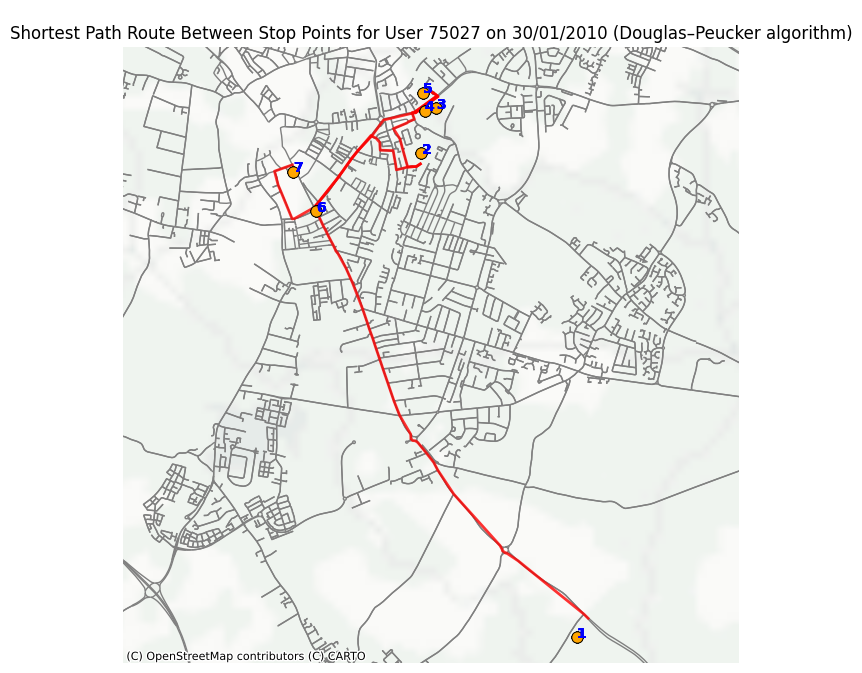

In [ ]:
dp1_df = dp_generalized1.df.reset_index()  # Extract lon and lat from the geometry
dp1_df['lon'] = dp1_df['geometry'].x
dp1_df['lat'] = dp1_df['geometry'].y
points = list(zip(dp1_df['lat'], dp1_df['lon']))  # (lat, lon) format

G = ox.graph_from_place('Cambridgeshire, UK', network_type='drive') #load road network of Cambridgeshire, UK because there is one coordinate that is located outside of city of Cambridge
nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in points] #get nearest nodes for routing

G_proj = ox.project_graph(G) #transform latitude and longitude to local CRS
crs_proj = G_proj.graph["crs"] #extracts the new CRS object

projector = pyproj.Transformer.from_crs("EPSG:4326", crs_proj, always_xy=True) #convert from EPSG:4326 to the new projected CRS
projected_points = [projector.transform(lon, lat) for lat, lon in points]  #convert each latitude and longitude to x, y pair in the projected CRS

#calculating the shortest path
all_route_coords = []
for i in range(len(nodes) - 1): #loop goes through each nodes
    try:
        route = nx.shortest_path(G, nodes[i], nodes[i + 1], weight='length') #create the shortest path between i node and i+1 node
        route_coords = [(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in route] #get the coordinates of each nodes
        all_route_coords.append(LineString(route_coords)) #converts the route into a Line String
    except nx.NetworkXNoPath:
        print(f" No path between point {i} and {i + 1}") #print this if the two nodes arent connected

#calculating the length of each path
segment_distances_user1a = []
for i in range(len(nodes) - 1):
    try:
        # Compute shortest path length (in meters)
        length = nx.shortest_path_length(G, nodes[i], nodes[i + 1], weight='length') #calculates the total shortest distance path of each i node and i+1 node
        segment_distances_user1a.append(length) #add to the blank list
    except nx.NetworkXNoPath:
        print(f"No path between point {i} and {i + 1}") #print this if the two nodes arent connected


multi_route = MultiLineString(all_route_coords) #bundles all the shortest paths into multi string
fig, ax = ox.plot_graph(G_proj, node_size=0, edge_color='gray', show=False, close=False)

#Plot the route segments
for line in all_route_coords:
    x, y = line.xy
    ax.plot(x, y, color='red', linewidth=2, alpha=0.8)

# circle markers at each check-in location
for x, y in projected_points:
   for idx, (x, y) in enumerate(projected_points, start=1): #enumerate each x, y coordinates
    ax.plot(x, y, 'o', color='orange', markersize=8, markeredgecolor='black', markeredgewidth=0.5) #plot each coordinates with orange circle shape
    ax.text(x, y, str(idx), fontsize=10, color='blue', weight='bold') #add text of the index (or the order) of each coordinates

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Zoom to the study area
minx, miny, maxx, maxy = multi_route.bounds #extracts the minimum and the maximum of our x,y coordinates
buffer = 500  # 500 meters extra space on each side
width = (maxx - minx)
height = (maxy - miny)
max_side = max(width, height) + 2 * buffer #create a square buffer
center_x = (minx + maxx) / 2 #finds the center horizontally
center_y = (miny + maxy) / 2 #finds the center vertically
ax.set_xlim(center_x - max_side/2, center_x + max_side/2) #sets the horizontal view with the buffer from max_side
ax.set_ylim(center_y - max_side/2, center_y + max_side/2)  #sets the vertical view with the buffer from max_side

plt.axis('off')
plt.title("Shortest Path Route Between Stop Points for User 75027 on 30/01/2010 (Douglas–Peucker algorithm)")
plt.show()


#Code source: (Law et al., 2025a:; OpenAI, 2025s)

In [ ]:
# Summarise metrics User 75027 on 30/01/2010 (Generalized)
if segment_distances_user1a:
    max_displacement = max(segment_distances_user1a)
    avg_displacement = sum(segment_distances_user1a) / len(segment_distances_user1a)
    total_distance = sum(segment_distances_user1a)

    print(f"Total distance: {total_distance:.2f} meters")
    print(f"Average displacement: {avg_displacement:.2f} meters")
    print(f"Maximum displacement: {max_displacement:.2f} meters")
else:
    print("No valid route segments found")
print(segment_distances_user1a)

#Code source: (Law et al., 2025b; OpenAI, 2025l)

Total distance: 12690.28 meters
Average displacement: 2115.05 meters
Maximum displacement: 7583.29 meters
[np.float64(7583.292512829803), np.float64(1307.0168169700094), np.float64(303.17536650846074), np.float64(401.5745662406092), np.float64(2026.2208348422516), np.float64(1069.0040840469162)]


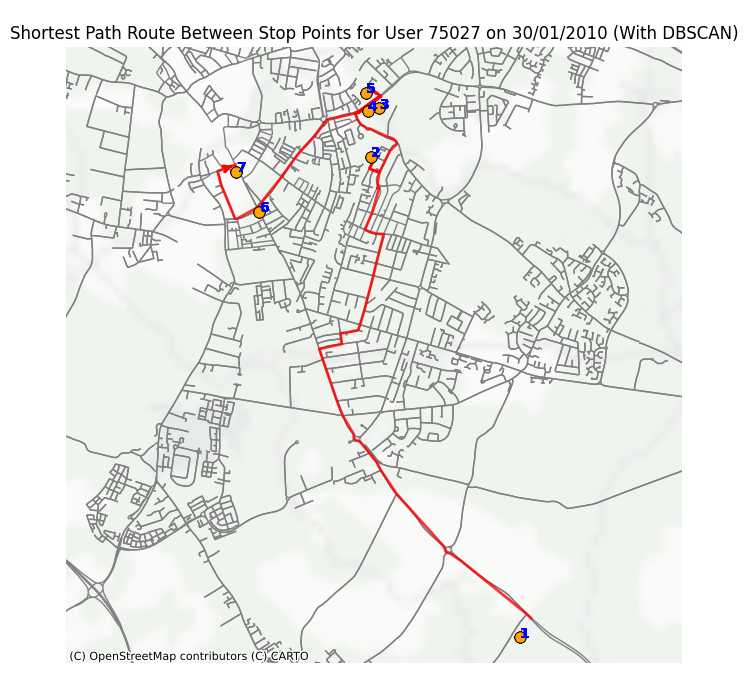

In [ ]:
# Original check-in coordinates of User 75027 on 30/01/2010 (With DBSCAN)
lats = [52.15722, 52.20492, 52.2052, 52.20565, 52.20982, 52.20949, 52.21132, 52.19895, 52.20286]
lons = [0.17301, 0.14561, 0.14452, 0.14483, 0.14659, 0.14479, 0.14442, 0.12761, 0.12364]
raw_points = list(zip(lats, lons))

# Cluster points using DBSCAN (2 meter threshold)
coords = np.array(raw_points) #converts the x,y coordinates into a NumPy array
clustering = DBSCAN(eps=0.00002, min_samples=1, metric='haversine').fit(np.radians(coords)) #groups coordinates that are close together based on distance (min 2 meters and use Haversine distance)
labels = clustering.labels_ #label the cluster
unique_indices = [np.where(labels == i)[0][0] for i in np.unique(labels)] #Take the first label as the representative
points = [raw_points[i] for i in unique_indices] #create a new list points based from the representatives

G = ox.graph_from_place('Cambridgeshire, UK', network_type='drive') #load road network of Cambridgeshire, UK because there is one coordinate that is located outside of city of Cambridge
nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in points] #get nearest nodes for routing

G_proj = ox.project_graph(G) #transform latitude and longitude to local CRS
crs_proj = G_proj.graph["crs"] #extracts the new CRS object

projector = pyproj.Transformer.from_crs("EPSG:4326", crs_proj, always_xy=True) #convert from EPSG:4326 to the new projected CRS
projected_points = [projector.transform(lon, lat) for lat, lon in points]  #convert each latitude and longitude to x, y pair in the projected CRS


#calculating the shortest path
all_route_coords = []
for i in range(len(nodes) - 1): #loop goes through each nodes
    try:
        route = nx.shortest_path(G, nodes[i], nodes[i + 1], weight='length') #create the shortest path between i node and i+1 node
        route_coords = [(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in route] #get the coordinates of each nodes
        all_route_coords.append(LineString(route_coords)) #converts the route into a Line String
    except nx.NetworkXNoPath:
        print(f" No path between point {i} and {i + 1}") #print this if the two nodes arent connected


#calculating the length of each path
segment_distances_user1 = []
for i in range(len(nodes) - 1):
    try:
        # Compute shortest path length (in meters)
        length = nx.shortest_path_length(G, nodes[i], nodes[i + 1], weight='length') #calculates the total shortest distance path of each i node and i+1 node
        segment_distances_user1.append(length) #add to the blank list
    except nx.NetworkXNoPath:
        print(f"No path between point {i} and {i + 1}") #print this if the two nodes arent connected


#Stop/Stay Points detection
detector = mpd.TrajectoryStopDetector(dp_generalized1) #Analyze the trajectory to find stop points
stop_points = detector.get_stop_points(min_duration=timedelta(seconds=300), max_diameter=100) #the user will be counted as stopping at one of the coordinate if they stay within 100 meter of the coordinate for at least 5 minutes
if not stop_points.empty:
    stop_points.crs = "EPSG:4326"
    stop_gdf_proj = stop_points.to_crs(crs_proj) #transform into the projected CRS
    for geom in stop_gdf_proj.geometry:
        ax.plot(geom.x, geom.y, 'o', color='red', markersize=8) #Plot red stop points if found

multi_route = MultiLineString(all_route_coords) #bundles all the shortest paths into multi string
fig, ax = ox.plot_graph(G_proj, node_size=0, edge_color='gray', show=False, close=False)

#Plot the route segments
for line in all_route_coords:
    x, y = line.xy
    ax.plot(x, y, color='red', linewidth=2, alpha=0.8)

# circle markers at each check-in location
for x, y in projected_points:
   for idx, (x, y) in enumerate(projected_points, start=1): #enumerate each x, y coordinates
    ax.plot(x, y, 'o', color='orange', markersize=8, markeredgecolor='black', markeredgewidth=0.5) #plot each coordinates with orange circle shape
    ax.text(x, y, str(idx), fontsize=10, color='blue', weight='bold') #add text of the index (or the order) of each coordinates

# Add arrow at end of last route
if all_route_coords:
    last_line = all_route_coords[-1] #extract the last line of the route
    x, y = last_line.xy #extract the last coordinate of the last line of the route
    if len(x) >= 2:
        ax.annotate(
            '',
            xy=(x[-1], y[-1]), xycoords='data',
            xytext=(x[-2], y[-2]), textcoords='data',
            arrowprops=dict(arrowstyle="->", color='red', lw=2.5),
        ) #drawing arrow between the last two points


# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Zoom to the study area
minx, miny, maxx, maxy = multi_route.bounds #extracts the minimum and the maximum of our x,y coordinates
buffer = 500  # 500 meters extra space on each side
width = (maxx - minx)
height = (maxy - miny)
max_side = max(width, height) + 2 * buffer #create a square buffer
center_x = (minx + maxx) / 2 #finds the center horizontally
center_y = (miny + maxy) / 2 #finds the center vertically
ax.set_xlim(center_x - max_side/2, center_x + max_side/2) #sets the horizontal view with the buffer from max_side
ax.set_ylim(center_y - max_side/2, center_y + max_side/2)  #sets the vertical view with the buffer from max_side

plt.axis('off')
plt.title("Shortest Path Route Between Stop Points for User 75027 on 30/01/2010 (With DBSCAN)")
plt.show()

#Code source: (Law et al., 2025a; Law et al., 2025b; Moses and Westermann, 2017; OpenAI, 2025s; OpenAI, 2025o)

In [ ]:
# Summarise metrics  User 75027 on 30/01/2010 (With DBSCAN)
if segment_distances_user1:
    max_displacement = max(segment_distances_user1)
    avg_displacement = sum(segment_distances_user1) / len(segment_distances_user1)
    total_distance = sum(segment_distances_user1)

    print(f"Total distance: {total_distance:.2f} meters")
    print(f"Average displacement: {avg_displacement:.2f} meters")
    print(f"Maximum displacement: {max_displacement:.2f} meters")
else:
    print("No valid route segments found")
print(segment_distances_user1)

#Code source: (Law et al., 2025b; OpenAI, 2025l)

Total distance: 12139.56 meters
Average displacement: 2023.26 meters
Maximum displacement: 6781.73 meters
[np.float64(6781.731482673846), np.float64(1557.8530623725637), np.float64(303.17536650846074), np.float64(401.5745662406092), np.float64(2026.2208348422516), np.float64(1069.0040840469162)]


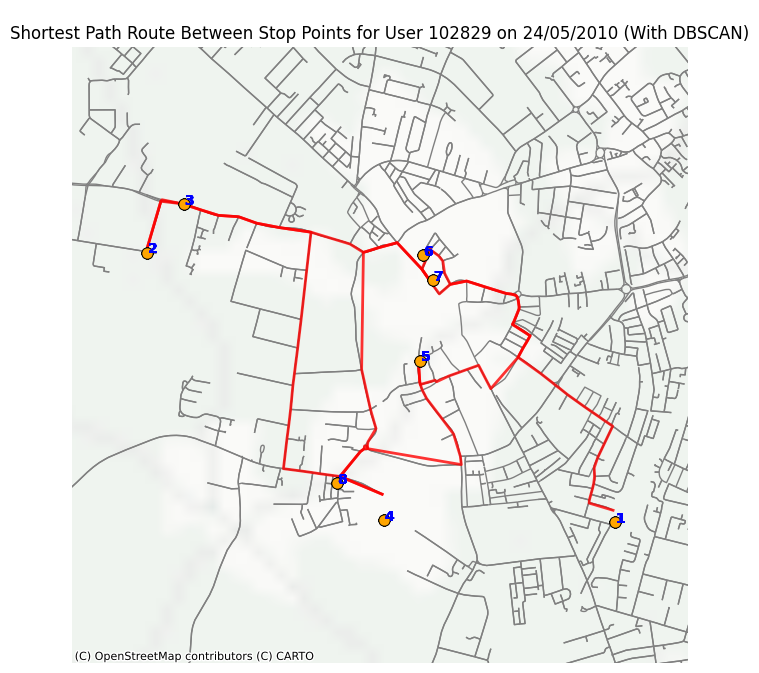

In [ ]:
# Original check-in coordinates of User 102829 on 24/05/2010 (With DBSCAN)
lats = [52.19441, 52.20953, 52.21254, 52.194, 52.20367, 52.21003, 52.20856, 52.19611]
lons = [0.1375, 0.09058, 0.094, 0.11481, 0.11777, 0.11766, 0.11866, 0.11012]
raw_points = list(zip(lats, lons))

# Cluster points using DBSCAN (2 meter threshold)
coords = np.array(raw_points) #converts the x,y coordinates into a NumPy array
clustering = DBSCAN(eps=0.00002, min_samples=1, metric='haversine').fit(np.radians(coords)) #groups coordinates that are close together based on distance (min 2 meters and use Haversine distance)
labels = clustering.labels_ #label the cluster
unique_indices = [np.where(labels == i)[0][0] for i in np.unique(labels)] #Take the first label as the representative
points = [raw_points[i] for i in unique_indices] #create a new list points based from the representatives

G = ox.graph_from_place('Cambridgeshire, UK', network_type='drive') #load road network of Cambridgeshire, UK because there is one coordinate that is located outside of city of Cambridge
nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in points] #get nearest nodes for routing

G_proj = ox.project_graph(G) #transform latitude and longitude to local CRS
crs_proj = G_proj.graph["crs"] #extracts the new CRS object

projector = pyproj.Transformer.from_crs("EPSG:4326", crs_proj, always_xy=True) #convert from EPSG:4326 to the new projected CRS
projected_points = [projector.transform(lon, lat) for lat, lon in points]  #convert each latitude and longitude to x, y pair in the projected CRS


#calculating the shortest path
all_route_coords = []
for i in range(len(nodes) - 1): #loop goes through each nodes
    try:
        route = nx.shortest_path(G, nodes[i], nodes[i + 1], weight='length') #create the shortest path between i node and i+1 node
        route_coords = [(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in route] #get the coordinates of each nodes
        all_route_coords.append(LineString(route_coords)) #converts the route into a Line String
    except nx.NetworkXNoPath:
        print(f" No path between point {i} and {i + 1}") #print this if the two nodes arent connected


#calculating the length of each path
segment_distances_user2 = []
for i in range(len(nodes) - 1):
    try:
        # Compute shortest path length (in meters)
        length = nx.shortest_path_length(G, nodes[i], nodes[i + 1], weight='length') #calculates the total shortest distance path of each i node and i+1 node
        segment_distances_user2.append(length) #add to the blank list
    except nx.NetworkXNoPath:
        print(f"No path between point {i} and {i + 1}") #print this if the two nodes arent connected


#Stop/Stay Points detection
detector = mpd.TrajectoryStopDetector(dp_generalized1) #Analyze the trajectory to find stop points
stop_points = detector.get_stop_points(min_duration=timedelta(seconds=300), max_diameter=100) #the user will be counted as stopping at one of the coordinate if they stay within 100 meter of the coordinate for at least 5 minutes
if not stop_points.empty:
    stop_points.crs = "EPSG:4326"
    stop_gdf_proj = stop_points.to_crs(crs_proj) #transform into the projected CRS
    for geom in stop_gdf_proj.geometry:
        ax.plot(geom.x, geom.y, 'o', color='red', markersize=8) #Plot red stop points if found

multi_route = MultiLineString(all_route_coords) #bundles all the shortest paths into multi string
fig, ax = ox.plot_graph(G_proj, node_size=0, edge_color='gray', show=False, close=False)

#Plot the route segments
for line in all_route_coords:
    x, y = line.xy
    ax.plot(x, y, color='red', linewidth=2, alpha=0.8)

# circle markers at each check-in location
for x, y in projected_points:
   for idx, (x, y) in enumerate(projected_points, start=1): #enumerate each x, y coordinates
    ax.plot(x, y, 'o', color='orange', markersize=8, markeredgecolor='black', markeredgewidth=0.5) #plot each coordinates with orange circle shape
    ax.text(x, y, str(idx), fontsize=10, color='blue', weight='bold') #add text of the index (or the order) of each coordinates

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Zoom to the study area
minx, miny, maxx, maxy = multi_route.bounds #extracts the minimum and the maximum of our x,y coordinates
buffer = 500  # 500 meters extra space on each side
width = (maxx - minx)
height = (maxy - miny)
max_side = max(width, height) + 2 * buffer #create a square buffer
center_x = (minx + maxx) / 2 #finds the center horizontally
center_y = (miny + maxy) / 2 #finds the center vertically
ax.set_xlim(center_x - max_side/2, center_x + max_side/2) #sets the horizontal view with the buffer from max_side
ax.set_ylim(center_y - max_side/2, center_y + max_side/2)  #sets the vertical view with the buffer from max_side

plt.axis('off')
plt.title("Shortest Path Route Between Stop Points for User 102829 on 24/05/2010 (With DBSCAN)")
plt.show()

#Code source: (Law et al., 2025a; Law et al., 2025b; Moses and Westermann, 2017; OpenAI, 2025s; OpenAI, 2025o)

In [ ]:
# Summarise metrics User 102829 on 24/05/2010 (With DBSCAN)
if segment_distances_user2:
    max_displacement = max(segment_distances_user2)
    avg_displacement = sum(segment_distances_user2) / len(segment_distances_user2)
    total_distance = sum(segment_distances_user2)

    print(f"Total distance: {total_distance:.2f} meters")
    print(f"Average displacement: {avg_displacement:.2f} meters")
    print(f"Maximum displacement: {max_displacement:.2f} meters")
else:
    print("No valid route segments found")
print(segment_distances_user2)

#Code source: (Law et al., 2025b; OpenAI, 2025l)

Total distance: 15603.39 meters
Average displacement: 2229.06 meters
Maximum displacement: 5023.12 meters
[np.float64(5023.123124020509), np.float64(503.71902721437084), np.float64(3172.7722456362812), np.float64(2049.2989877331415), np.float64(2316.318225183238), np.float64(248.02756983036747), np.float64(2290.1313065417435)]


### Mobility Patterns: Question 3 (Urban Planning Application Question)

Using the Gowalla dataset, the author also attempted to propose the development of a new community park in Cambridge. This recommendation aligns with the ongoing initiatives of the Cambridge City Council, which is actively working to enhance green spaces across the city (Greater Cambridge Planning Service, 2021). Urban green spaces have been shown to improve the quality of the public cohesion, promote health and well-being, and contribute to climate change mitigation by providing shade and cooling through evapotranspiration (Brown, 2025). Moreover, green infrastructure is considered integral to Cambridge's character which shaped by its abundant parks, trees, and natural landscapes. These benefits not only enhance livability but also produce valueable economic benefits (Cohen, Burrowes, & Gwam, 2022).

To identify a suitable location for a new community park, this study first examines the Green Space Deprivation Index across wards in the city of Cambridge, as reported by Friends of the Earth (2020). The index is based on the proportion of the population living within a five-minute walk of at least two hectares of public green space, as well as the total green space per area in 2020. The analysis reveals notable deprivation in the northern and southeastern wards of the city.

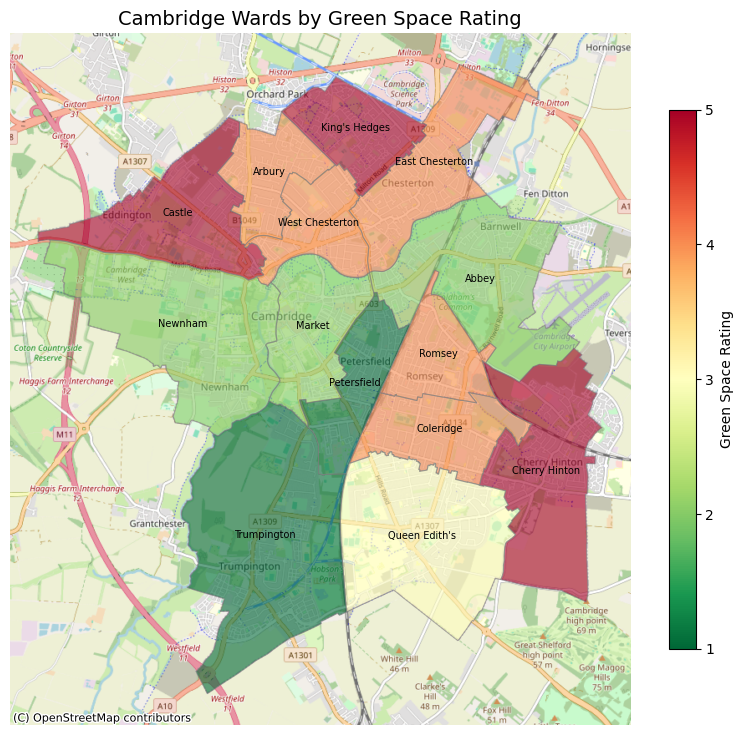

In [ ]:
#Loading Datasets
geojson_path = os.path.join(base_path, 'WD_MAY_2023_UK_BFC_-6713663680658858762.geojson')
gdf = gpd.read_file(geojson_path)
csv_path = os.path.join(base_path, 'Cambridge Green Space Rating.csv')
rating_df = pd.read_csv(csv_path)


#Merging Datasets
merged_gdf = gdf.merge(rating_df, left_on='WD23NM', right_on='Wards', how='left')
merged_gdf = merged_gdf.to_crs(epsg=3857) #change the crs to Web Mercator for overlaying it with OSM basemap

#Create the Plot
fig, ax = plt.subplots(figsize=(10, 10))
merged_gdf.plot(
    column='Green Space Rating',
    cmap='RdYlGn_r',
    linewidth=0.8,
    edgecolor='gray',
    ax=ax,
    alpha=0.6,
    legend=True,
    legend_kwds={
        'ticks': [1, 2, 3, 4, 5],
        'label': 'Green Space Rating',
        'shrink': 0.7
    }
)


# Label the Wards
for idx, row in merged_gdf.iterrows():
    if row['geometry'].centroid.is_valid:
        plt.annotate(
            text=row['WD23NM'],
            xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
            ha='center',
            fontsize=7,
            color='black'
        )


#Add Basemap and plot the map
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=merged_gdf.crs)
ax.set_axis_off()
ax.set_title('Cambridge Wards by Green Space Rating', fontdict={'fontsize': 14})
plt.show()

#Code source: (OpenAI,2025r; OpenAI, 2025b)

This study focuses on the area surrounding King's Hedges ward in Cambridge as a proposed site for a new community park. King's Hedges was selected due to its notably poor access to green spaces, as indicated by its low green space rating. Additionally, the ward contains the highest number of Lower Super Output Areas (LSOAs) ranked among the most deprived in the 2019 Index of Multiple Deprivation. Given the well-documented socioeconomic and monetary benefits of community parks, this location presents a strong case for targeted green space development.

Upon closer examination of King's Hedges ward, two green spaces were identified in the northern part of the area. As a result, the proposed location for a new community park was selected in the southern part of the ward, near the border with East Chesterton. This southern section is predominantly residential, and residents would greatly benefit from improved access to green spaces.

Although the map indicates several small green areas in this southern region, verification against official community park location data from Cambridge City Council (2025) revealed that most of these are either private gardens or very small playgrounds. The green space data was derived from OpenStreetMap, which may include inaccuracies. This is can be one of the limitation of this study is the inability to further validate the status, quality, or maintenance levels of these green spaces.

Based on these findings, a suitable location for a new community park would be between the King’s Hedges and East Chesterton wards. This placement would improve accessibility for residents to green community park in the southern part of King’s Hedges and benefit East Chesterton, which also exhibits high levels of green space deprivation.

<ipython-input-14-3d4373908466>:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kings_hedges_center = kings_hedges_gdf.to_crs('EPSG:4326').geometry.centroid.iloc[0] #Reproject kings_hedges_gdf to EPSG:4326 and get the centroid of the ward


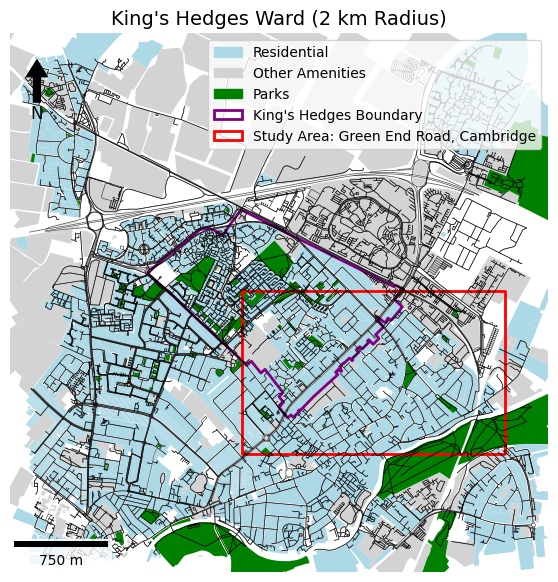

In [ ]:
place_name = "Cambridge, UK"
target_crs = 'EPSG:27700'  # British national grid


kings_hedges_gdf = merged_gdf[merged_gdf['WD23NM'] == "King's Hedges"]
if kings_hedges_gdf.crs is None:
    kings_hedges_gdf = kings_hedges_gdf.set_crs('EPSG:4326') #fix CRS if missing
kings_hedges_gdf_proj = kings_hedges_gdf.to_crs(target_crs) #set crs to British national grid
kings_hedges_center = kings_hedges_gdf.to_crs('EPSG:4326').geometry.centroid.iloc[0] #Reproject kings_hedges_gdf to EPSG:4326 and get the centroid of the ward

#Download street network and landuse
G_walk = ox.graph_from_point((kings_hedges_center.y, kings_hedges_center.x), dist=2000, network_type='all') #download the street network for all network type within 2 km radius from the centroid
G_proj = ox.project_graph(G_walk, to_crs=target_crs) #set crs to British national grid
gdf_edges = ox.graph_to_gdfs(G_proj, nodes=False) #extract the street network as edges
tags = {'landuse': True, 'leisure': 'park'}
landuse_gdf = ox.features_from_point((kings_hedges_center.y, kings_hedges_center.x),
                                     dist=2000, tags=tags) #download landuse and green spaces/parks within the same 2 km from the centroid
if landuse_gdf.crs is None:
    landuse_gdf = landuse_gdf.set_crs('EPSG:4326') #fix CRS if missing
landuse_gdf = landuse_gdf[landuse_gdf.geom_type.isin(['Polygon', 'MultiPolygon'])] #keep only polygons
landuse_gdf = landuse_gdf.to_crs(target_crs)  #set crs to British national grid

residential_gdf = landuse_gdf[landuse_gdf['landuse'] == 'residential'] #filter landuse to only residential areas
parks_gdf = landuse_gdf[landuse_gdf['leisure'] == 'park'] #filter landuse to only green spaces/parks
other_landuse_gdf = landuse_gdf[
    ~(landuse_gdf.index.isin(residential_gdf.index) | landuse_gdf.index.isin(parks_gdf.index)) #set the rest of landuse as "others"
]


red_box = box(545550, 259900, 547650, 261200)  # (xmin, ymin, xmax, ymax) in EPSG:27700
red_box_gdf = gpd.GeoDataFrame(geometry=[red_box], crs=target_crs) #create red box for specific study area

# Plotting preparation
fig, ax = plt.subplots(figsize=(7, 7))
other_landuse_gdf.plot(ax=ax, color='lightgrey', edgecolor='none') #set the 'others' landuse as lightgrey
residential_gdf.plot(ax=ax, color='lightblue', edgecolor='none') #set the 'residential' landuse as lightblue
parks_gdf.plot(ax=ax, color='green', edgecolor='none') #set the 'green spaces/parks' landuse as green
gdf_edges.plot(ax=ax, color='black', linewidth=0.5, alpha=0.7)
kings_hedges_gdf_proj.plot(ax=ax, facecolor='none', edgecolor='purple', linewidth=2) #set the boundaries of King's Hedges as purple
red_box_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2) #red box for specific study area

bounds = gdf_edges.total_bounds
ax.set_xlim(bounds[0] - 100, bounds[2] + 100) #small margin horizontally
ax.set_ylim(bounds[1] - 100, bounds[3] + 100) #small margin vertically

#scalebar
scalebar = ScaleBar(dx=1, units="m", location='lower left', scale_loc='bottom', box_color='white', box_alpha=0.8)
ax.add_artist(scalebar)

#north arrow
arrow_props = dict(facecolor='black', width=5, headwidth=15)
ax.annotate('N',
            xy=(0.05, 0.95),
            xytext=(0.05, 0.85),
            arrowprops=arrow_props,
            ha='center', va='center', fontsize=12,
            xycoords='axes fraction')

#legend
legend_elements = [
    mpatches.Patch(color='lightblue', label='Residential'),
    mpatches.Patch(color='lightgrey', label='Other Amenities'),
    mpatches.Patch(color='green', label='Parks'),
    mpatches.Patch(facecolor='none', edgecolor='purple', linewidth=2, label="King's Hedges Boundary"),
    mpatches.Patch(facecolor='none', edgecolor='red', linewidth=2, label="Study Area: Green End Road, Cambridge")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

#plot
ax.set_axis_off()
plt.title("King's Hedges Ward (2 km Radius)", fontsize=14)
plt.show()

#Code source: (Law et al., 2025a; OpenAI, 2025p)

In this study, centrality analysis was employed to identify optimal locations for new community parks. When planning land acquisition for public green spaces, centrality measures can be used to optimize park placement and size in order to enhance network efficiency (Gyurkovich, 2023; Yin et al., 2022). Following the betweenness and closeness centrality analysis using a walking network, Green End Road emerged as the most central route, exhibiting the highest values in both metrics. This suggests that Green End Road serves as a key connector across the area. Based on these findings, this location is considered well-suited for a community park that could support healthier, more resilient, and socially cohesive communities within and around King’s Hedges ward.

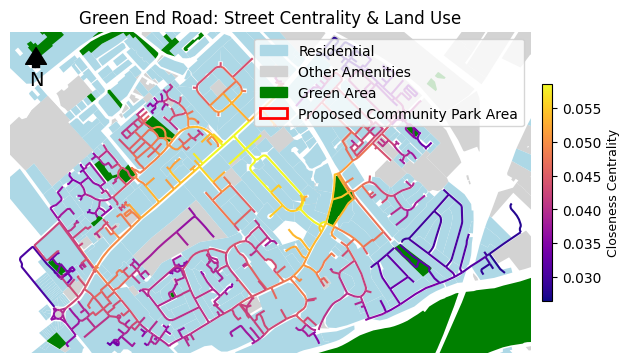

In [ ]:

G = ox.graph_from_address('Green End Road, Cambridge', dist=1000, network_type='walk') #download the walking network around Green End Road, Cambridge within 2 km radius
DG = nx.DiGraph(G) #convert into directed graph
edge_cc = nx.closeness_centrality(nx.line_graph(DG)) #calculates closeness centrality
nx.set_edge_attributes(DG, edge_cc, 'cc') #calculate closeness centrality for every edges


G1 = nx.MultiGraph(DG) #convert into multi graph
attr = 'cc'
cmap = 'plasma'
nc = ox.plot.get_edge_colors_by_attr(G1, attr, cmap=cmap) #displaying color for closeness centrality levels

#Download street network and landuse
tags = {'landuse': True, 'leisure': 'park'}
landuse_gdf = ox.features_from_address('Green End Road, Cambridge', dist=1000, tags=tags) #download landuse within 2 km radius
landuse_gdf = landuse_gdf[landuse_gdf.geom_type.isin(['Polygon', 'MultiPolygon'])] #keep only polygons
landuse_gdf = landuse_gdf.to_crs(ox.graph_to_gdfs(G, nodes=False).crs) #Convert street network into geodataframe and reprojects the landuse into the same CRS as the street network
residential_gdf = landuse_gdf[landuse_gdf['landuse'] == 'residential'] #filter landuse to only residential areas
parks_gdf = landuse_gdf[landuse_gdf['leisure'] == 'park'] #filter landuse to only green spaces/park areas
other_landuse_gdf = landuse_gdf[
    ~(landuse_gdf.index.isin(residential_gdf.index) | landuse_gdf.index.isin(parks_gdf.index)) #set other landuse category as others
]

# 🛠 7. Plot
fig, ax = plt.subplots(figsize=(7, 5))
other_landuse_gdf.plot(ax=ax, color='lightgrey', edgecolor='none') #set the 'others' landuse as lightgrey
residential_gdf.plot(ax=ax, color='lightblue', edgecolor='none') #set the 'residential' landuse as lightblue
parks_gdf.plot(ax=ax, color='green', edgecolor='none')  #set the 'green spaces/parks' landuse as green
ox.plot_graph(G1,
              ax=ax,
              node_size=0,
              node_color='w',
              node_edgecolor='gray',
              edge_color=nc,
              edge_linewidth=1.5,
              edge_alpha=1,
              bgcolor='none',
              show=False,
              close=False)

#north arrow
arrow_props = dict(facecolor='black', width=5, headwidth=15)
ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.85),
            arrowprops=arrow_props,
            ha='center', va='center', fontsize=14,
            xycoords='axes fraction')


#colorbar
sm = cm.ScalarMappable(cmap=cmap,
                       norm=mcolors.Normalize(vmin=min(nx.get_edge_attributes(G1, attr).values()),
                                              vmax=max(nx.get_edge_attributes(G1, attr).values()))) #Normalize the data values to the 0-1 range based on the minimum and maximum values
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Closeness Centrality', fontsize=9)

#legend
legend_elements = [
    mpatches.Patch(color='lightblue', label='Residential'),
    mpatches.Patch(color='lightgrey', label='Other Amenities'),
    mpatches.Patch(color='green', label='Green Area'),
    mpatches.Patch(facecolor='none', edgecolor='red', linewidth=2, label='Proposed Community Park Area')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)


ax.set_axis_off()
plt.title('Green End Road: Street Centrality & Land Use', fontsize=12)
plt.show()

#Code source: (Law et al., 2025a; OpenAI, 2025i)

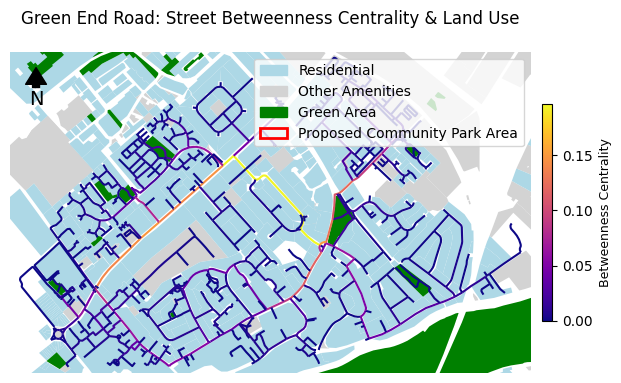

In [ ]:

G = ox.graph_from_address('Green End Road, Cambridge', dist=1000, network_type='walk') #download the walking network around Green End Road, Cambridge within 2 km radius
DG = nx.DiGraph(G) #convert into directed graph
edge_bc = nx.betweenness_centrality(nx.line_graph(DG)) #calculates betweeness centrality
nx.set_edge_attributes(DG, edge_bc, 'bc')  #calculate betweeness centrality for every edges

G1 = nx.MultiGraph(DG) #convert into multi graph
attr = 'bc'
cmap = 'plasma'
nc = ox.plot.get_edge_colors_by_attr(G1, attr, cmap=cmap) #displaying color for betweeness centrality levels

#Download street network and landuse
tags = {'landuse': True, 'leisure': 'park'}
landuse_gdf = ox.features_from_address('Green End Road, Cambridge', dist=1000, tags=tags) #download landuse within 2 km radius
landuse_gdf = landuse_gdf[landuse_gdf.geom_type.isin(['Polygon', 'MultiPolygon'])] #keep only polygons
landuse_gdf = landuse_gdf.to_crs(ox.graph_to_gdfs(G, nodes=False).crs) #Convert street network into geodataframe and reprojects the landuse into the same CRS as the street network
residential_gdf = landuse_gdf[landuse_gdf['landuse'] == 'residential'] #filter landuse to only residential areas
parks_gdf = landuse_gdf[landuse_gdf['leisure'] == 'park'] #filter landuse to only green spaces/park areas
other_landuse_gdf = landuse_gdf[
    ~(landuse_gdf.index.isin(residential_gdf.index) | landuse_gdf.index.isin(parks_gdf.index)) #set other landuse category as others
]

#Plot
fig, ax = plt.subplots(figsize=(7, 5))
other_landuse_gdf.plot(ax=ax, color='lightgrey', edgecolor='none') #set the 'others' landuse as lightgrey
residential_gdf.plot(ax=ax, color='lightblue', edgecolor='none') #set the 'residential' landuse as lightblue
parks_gdf.plot(ax=ax, color='green', edgecolor='none')  #set the 'green spaces/parks' landuse as green
ox.plot_graph(G1,
              ax=ax,
              node_size=0,
              node_color='w',
              node_edgecolor='gray',
              edge_color=nc,
              edge_linewidth=1.5,
              edge_alpha=1,
              bgcolor='none',
              show=False,
              close=False)

#north arrow
arrow_props = dict(facecolor='black', width=5, headwidth=15)
ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.85),
            arrowprops=arrow_props,
            ha='center', va='center', fontsize=14,
            xycoords='axes fraction')


#colorbar
sm = cm.ScalarMappable(cmap=cmap,
                       norm=mcolors.Normalize(vmin=min(nx.get_edge_attributes(G1, attr).values()),
                                              vmax=max(nx.get_edge_attributes(G1, attr).values()))) #Normalize the data values to the 0-1 range based on the minimum and maximum values
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Betweenness Centrality', fontsize=9)

#legend
legend_elements = [
    mpatches.Patch(color='lightblue', label='Residential'),
    mpatches.Patch(color='lightgrey', label='Other Amenities'),
    mpatches.Patch(color='green', label='Green Area'),
    mpatches.Patch(facecolor='none', edgecolor='red', linewidth=2, label='Proposed Community Park Area')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

ax.set_axis_off()
plt.title('Green End Road: Street Betweenness Centrality & Land Use', fontsize=12, pad=20)
plt.show()

#Code source: (Law et al., 2025a; OpenAI, 2025i)

### Conclusion

This mobility analysis demonstrates that the Gowalla Cambridge dataset can effectively capture individual check-in patterns and their spatial characteristics, while also supporting the identification of suitable locations for new community infrastructure, such as parks. The techniques applied in this study are transferable and may be adapted for future research across different geographic contexts.

Although these analyses enable the development of intelligent applications, they also present notable limitations, particularly regarding privacy. In the analysis of individual mobility patterns and check-in behaviors, there is a risk of re-identifying individuals, as personal identities can often be inferred from frequently visited locations. This poses serious privacy concerns, especially if the data are analyzed with malicious intent (Pellungrini et al., 2018; Krishnamurthy & Pelechrinis, 2013; Mattos et al., 2022; Andrienko, Andrienko & Fuchs, 2013). To mitigate these risks, the k-anonymity technique can be applied, ensuring that each individual is indistinguishable from at least k others based on quasi-identifiers—attributes (Pellungrini et al., 2018).

While the proposed new community park offers valuable insights, there are limitations to consider. Neither individual centrality measures nor the compound centrality index should be used as stand-alone tools for urban policy, as they do not account for other critical variables such as park quality, amenities, legal constraints, or precise location data. Future research should incorporate additional dimensions such as legal feasibility (Ojeda-Revah, Bojorquez, & Osuna, 2017), inclusive design (Moore, Boyle, & Lynch, 2022), and safety consideration (Yiliu, Hussain, & Shukor, 2025) to name a few for a more comprehensive approach in designing new community park (Gyurkovich, 2023).




## Machine Learning Analysis with Venue Review Data in Calgary, Canada

Given the vast volume of unstructured data generated daily, from medical records to social media, automated methods are essential for efficiently analyzing text data (Akrivia Health, 2022). In the business domain, textual reviews offer valuable semantic information for modeling users and items, which can improve rating predictions in recommendation systems and provide insights into how customers perceive products and services (Wang et al., 2019; Monett & Stolte, 2016). Beyond commercial applications, review texts can also support urban planning by revealing social dynamics and informing the development of new amenities (Rahimi, Mottahedi & Liu, 2018).

The combination of text analysis and building amenities has been explored in several studies. Shihab et al. (2018), for instance, applied machine learning algorithms, such as Support Vector Machines, Decision Trees, and Logistic Regression, to Yelp review data to identify optimal locations for restaurant businesses. Similarly, Sun and Paule (2017) analyzed Yelp ratings in Phoenix, USA, and found that spatial clusters of highly rated restaurants often exhibited similar characteristics. Tayeen, Mtibaa, and Misra (2019) also utilized Yelp data to evaluate the influence of location on a restaurant's success.

This study analyzes venue review data in Calgary, Canada, with a focus on restaurants, the most frequently reviewed amenity in the dataset. Supervised machine learning models, including logistic regression, multinomial Naive Bayes, and random forest, are applied to predict review scores based on textual review content. In addition, spatial and centrality analyses are conducted to identify optimal locations for new restaurant development, leveraging insights extracted from the review data.

### Venue Review Data: Question 1 (Loading and cleaning the textual dataset)

Prior to analysis, the dataset was cleaned by filtering for reviews related specifically to restaurants and food-related amenities, as these categories contained the highest volume of reviews. Text preprocessing steps included converting text to lowercase, removing stopwords, lemmatization, and word filtering to ensure consistency and improve analytical accuracy. The dataset also included user-generated tags—'useful,' 'funny,' and 'cool'—which reflect peer validation of reviews. These tags were deemed valuable indicators of perceived review quality and were therefore incorporated into the machine learning analysis. Finally, TF-IDF vectorization was used instead of a Count Vectorizer, as prior studies have shown that TF-IDF often yields better model performance in text classification tasks (Suryaningrum, 2023; Rakhmanov, 2020).

In [ ]:
csv_path = os.path.join(base_path, 'Calgary.csv')
df = pd.read_csv(csv_path)

In [ ]:
unique_categories = df["categories"].dropna().unique() #get the unique categories

all_categories = []
for entry in unique_categories:
    items = [cat.strip() for cat in entry.split(',')] #splits the category by comma
    all_categories.extend(items)

category_counts = Counter(all_categories)
top_30 = category_counts.most_common(30)

top_30_df = pd.DataFrame(top_30, columns=["Category", "Frequency"]) #sort top 30 most frequent categories
print(top_30_df)

                     Category  Frequency
0                 Restaurants       1350
1                    Shopping        922
2                        Food        764
3               Beauty & Spas        410
4                   Nightlife        400
5                        Bars        367
6            Health & Medical        340
7               Home Services        320
8                  Automotive        320
9              Local Services        284
10                Active Life        231
11                    Fashion        219
12               Coffee & Tea        201
13  Event Planning & Services        199
14              Home & Garden        198
15                Auto Repair        188
16             Canadian (New)        182
17                  Fast Food        169
18                 Sandwiches        159
19             Specialty Food        159
20         Breakfast & Brunch        158
21                      Pizza        148
22               Hair Removal        146
23       Arts & 

In [ ]:
nltk.download('punkt') #splits text into words
nltk.download('stopwords') #donwload stop words
nltk.download('wordnet') #database used for lemmatization
nltk.download('punkt_tab') #NLTK Downloader

#stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer() #initializes a lemmatizer

#cleaning function
def clean_text_nltk(text):
    if pd.isnull(text):
        return "" #return an empty string if the text is missing
    tokens = nltk.word_tokenize(text) #tokenize the text
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha()] #lemmatize each word
    return " ".join(tokens) #join the text into one single string


df = df[df['categories'].str.contains(r'Restaurants|Food', case=False, na=False)] # Filter amenities categories that contain the word "Restaurants" or "Food"
df['cleaned_text'] = df['text'].apply(clean_text_nltk) #clean the review text
df['cleaned_categories'] = df['categories'].apply(clean_text_nltk) #clean the category

df['polarity'] = df['stars_y'].apply(lambda x: 1 if x >= 4 else 0) #classifying the review stars to positive and negative
y = df['polarity']

corpus_text = df['cleaned_text'].tolist() #convert cleaned review text into list
vectorizer_text = TfidfVectorizer(lowercase=True, stop_words='english', min_df=2, max_df=0.95) #turns the text into numerical vectors with TF-IDF vectorizer (make every words into lowecase, remove stop words, and remove very common and rare words)
X_text = vectorizer_text.fit_transform(corpus_text) #fit the cleaned text with the TF-IDF vectorizer
vectorizer_text_ngram = TfidfVectorizer(ngram_range=(2, 3),lowercase=True, stop_words='english', min_df=2, max_df=0.95) #fit the text with the TF-IDF vectorizer for bigram-trigram version
X_text_ngram = vectorizer_text_ngram.fit_transform(corpus_text)  #fit the cleaned text with the TF-IDF vectorizer (bigram-trigram version)

#Preparing non-text features
non_text_features = df[['useful', 'funny', 'cool']].fillna(0) #add these non text features into the training
scaler = StandardScaler()
non_text_features_scaled = scaler.fit_transform(non_text_features) #standardizes the numeric features
X_combined = hstack([X_text, non_text_features_scaled])
X_combined_ngram = hstack([X_text_ngram, non_text_features_scaled])

#Code source: (Law et al., 2025a; OpenAI, 2025m)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Venue Review Data: Question 2 (Build a supervised learning model for text analysis)

This study employed three machine learning algorithms: Logistic Regression (Le, 2022; Sun, 2022; Shihab et al., 2018), Multinomial Naive Bayes (Reddy et al., 2017), and Random Forest (Reddy et al., 2017; Haq et al., 2022). These models are selected for their established effectiveness in predicting review star ratings from textual data. To properly evaluate model performance, macro-averaged F1 scores were used. This is especially relevant given the class imbalance in the dataset, where 67% of restaurant reviews were positive.

Notably, Reddy et al. (2017) found that a Bigram-Trigram Multinomial model performed particularly well in this task. Because of this insight, the author evaluated each model using both unigram and bigram-trigram text structures, resulting in six total model configurations. Furthermore, non-textual features were incorporated only in the Logistic Regression and Random Forest models, as the assumptions of the Multinomial Naive Bayes model, which is its reliance on discrete word frequency inputs, make it unsuitable for handling continuous data from the non-textual data (Xu, Li, & Wang, 2017; GeeksforGeeks, 2023).

Overall, unigram models outperformed their bigram–trigram counterparts, with an average macro F1 score of 0.82 compared to 0.75. The best-performing model was the unigram logistic regression, achieving a macro F1 score of 0.86, indicating strong overall performance in terms of precision and recall despite class imbalance (Mathew et al., 2023; Buhl, 2023). The confusion matrix further supports this, showing high accuracy in both true positives and true negatives. In contrast, the bigram–trigram multinomial model yielded a lower macro F1 score of 0.71, which contradicts findings by Reddy et al. (2017), suggesting this model may not generalize well to the Calgary review dataset.

In [ ]:
#Unigram
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y) #Ensures the split maintains the same proportion of class labels in both training and testing sets

# Logistic Regression
lr = LogisticRegression(max_iter=1000) #logistic regression with maximum 1000 iterations
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)


# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42) #100 trees for the model
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)


# Multinomial Naive Bayes
X_text_train, X_text_test, y_train_text, y_test_text = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y) #use only the text data for the multinomial naive bayes
nb = MultinomialNB()
nb.fit(X_text_train, y_train_text)
y_pred_nb = nb.predict(X_text_test)
print("Multinomial Naive Bayes:\n")
print(classification_report(y_test_text, y_pred_nb))
cm_nb = confusion_matrix(y_test_text, y_pred_nb)


#Code source: (Law et al., 2025c; Law et al., 2025d)

Logistic Regression:

              precision    recall  f1-score   support

           0       0.86      0.76      0.81      3989
           1       0.89      0.94      0.91      7933

    accuracy                           0.88     11922
   macro avg       0.87      0.85      0.86     11922
weighted avg       0.88      0.88      0.88     11922

Random Forest:

              precision    recall  f1-score   support

           0       0.90      0.62      0.74      3989
           1       0.84      0.97      0.90      7933

    accuracy                           0.85     11922
   macro avg       0.87      0.79      0.82     11922
weighted avg       0.86      0.85      0.84     11922

Multinomial Naive Bayes:

              precision    recall  f1-score   support

           0       0.93      0.53      0.68      3989
           1       0.81      0.98      0.88      7933

    accuracy                           0.83     11922
   macro avg       0.87      0.76      0.78     11922
weighted a

In [ ]:
#Bigram-Trigram
X_train, X_test, y_train, y_test = train_test_split(X_combined_ngram, y, test_size=0.2, random_state=42, stratify=y) #Ensures the split maintains the same proportion of class labels in both training and testing sets

# Logistic Regression

lr = LogisticRegression(max_iter=1000) #logistic regression with maximum 1000 iterations
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))
cm_lr_ngram = confusion_matrix(y_test, y_pred_lr)

# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42) #100 trees for the model
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))
cm_rf_ngram = confusion_matrix(y_test, y_pred_rf)

# Model 3: Multinomial Naive Bayes
X_text_train, X_text_test, y_train_text, y_test_text = train_test_split(X_text_ngram, y, test_size=0.2, random_state=42, stratify=y) #use only the text data for the multinomial naive bayes
nb = MultinomialNB()
nb.fit(X_text_train, y_train_text)
y_pred_nb = nb.predict(X_text_test)
print("Multinomial Naive Bayes:\n")
print(classification_report(y_test_text, y_pred_nb))
cm_nb_ngram = confusion_matrix(y_test_text, y_pred_nb)

#Code source: (Law et al., 2025c; Law et al., 2025d)

Logistic Regression:

              precision    recall  f1-score   support

           0       0.89      0.54      0.67      3989
           1       0.81      0.97      0.88      7933

    accuracy                           0.82     11922
   macro avg       0.85      0.75      0.78     11922
weighted avg       0.83      0.82      0.81     11922

Random Forest:

              precision    recall  f1-score   support

           0       0.85      0.54      0.66      3989
           1       0.80      0.95      0.87      7933

    accuracy                           0.81     11922
   macro avg       0.83      0.75      0.77     11922
weighted avg       0.82      0.81      0.80     11922

Multinomial Naive Bayes:

              precision    recall  f1-score   support

           0       0.97      0.39      0.56      3989
           1       0.76      0.99      0.86      7933

    accuracy                           0.79     11922
   macro avg       0.87      0.69      0.71     11922
weighted a

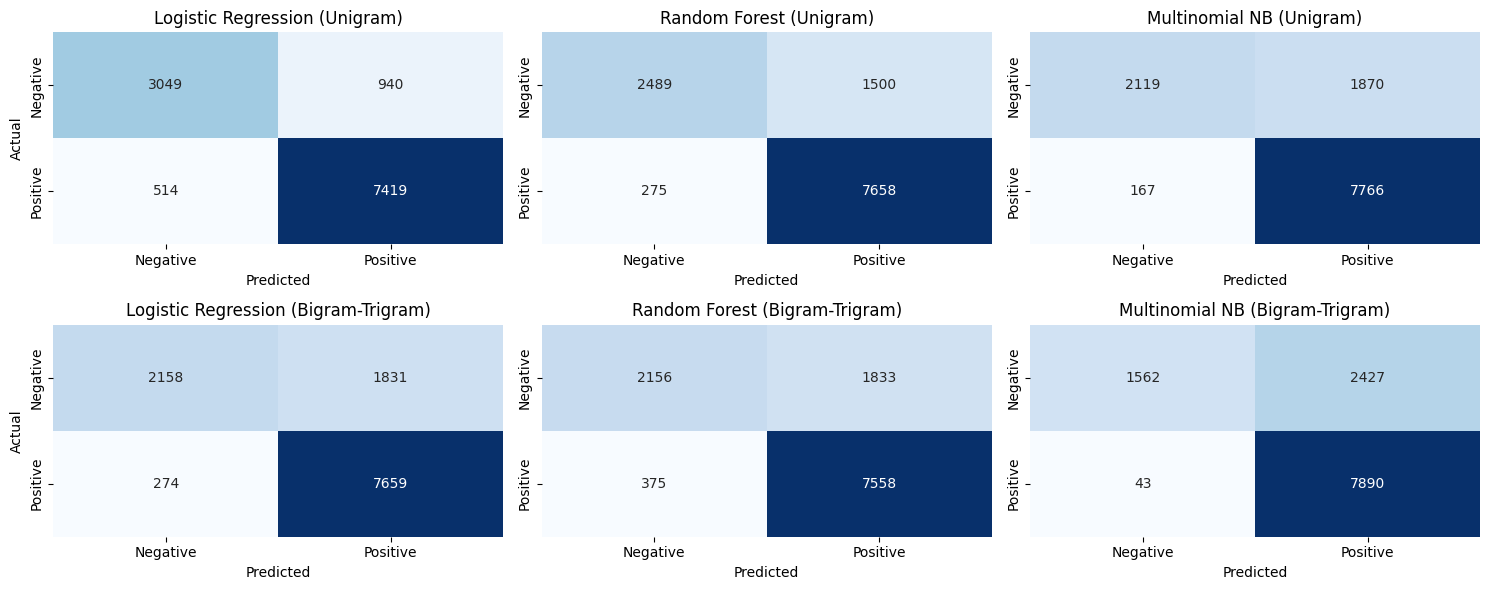

In [ ]:
#compiled confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression (Unigram)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[0, 1])
axes[0, 1].set_title('Random Forest (Unigram)')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[0, 2])
axes[0, 2].set_title('Multinomial NB (Unigram)')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('')

sns.heatmap(cm_lr_ngram, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[1, 0])
axes[1, 0].set_title('Logistic Regression (Bigram-Trigram)')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

sns.heatmap(cm_rf_ngram, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[1, 1])
axes[1, 1].set_title('Random Forest (Bigram-Trigram)')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('')

sns.heatmap(cm_nb_ngram, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[1, 2])
axes[1, 2].set_title('Multinomial NB (Bigram-Trigram)')
axes[1, 2].set_xlabel('Predicted')
axes[1, 2].set_ylabel('')

plt.tight_layout()
plt.show()

#Code source: (Law et al., 2025c; OpenAI, 2025c)

### Venue Review Data: Question 3 (Business Intelligence Application Question)

After conducting supervised machine learning analysis, the author also attempted to use the review dataset to identify promising locations for potential new restaurant development through combined text and spatial analysis. To validate the usefulness of the text data, a correlation analysis between the average star ratings and the average positive sentiment scores was conducted, yielding a coefficient of 0.786. This strong positive relationship suggests that sentiment scores derived from text analysis are reflective of star ratings and can serve as a proxy for public perception of restaurant quality.

Furthermore, to ensure the robustness of the analysis, the distribution of review counts per restaurant was then examined. The histogram revealed a heavy skew, with most restaurants having only one review. Such a limited number of reviews is insufficient to reliably assess quality. Therefore, a minimum threshold of 15 reviews, three above the dataset’s median of 12, was applied to focus the analysis on restaurants with a more representative sample of customer feedback.

<ipython-input-23-f79490ee9acf>:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['categories'].str.contains(r'\b(Restaurants|Food)\b', case=False, na=False) &
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Correlation between star rating and sentiment score: 0.786


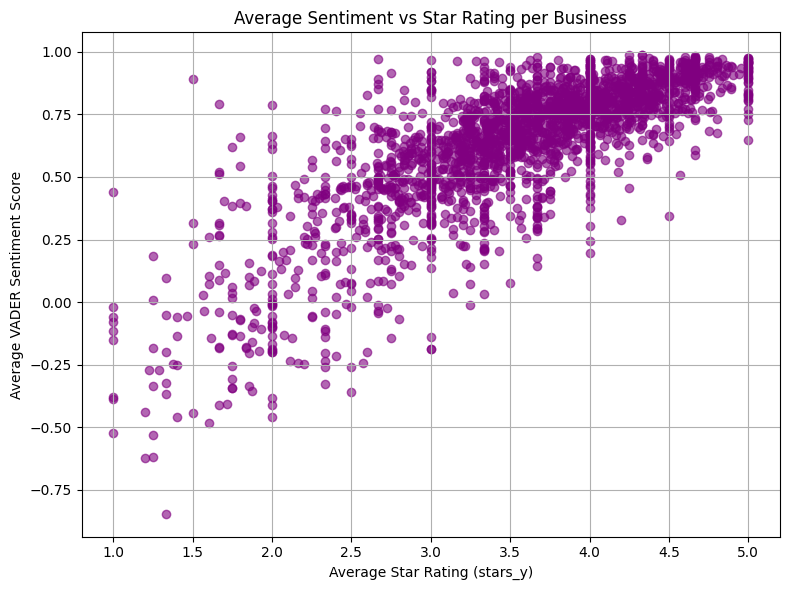

In [ ]:
restaurant_df = df[
    df['categories'].str.contains(r'\b(Restaurants|Food)\b', case=False, na=False) &
    df['latitude'].notnull() & df['longitude'].notnull()
]

business_review_counts = (
    restaurant_df.groupby('business_id')['review_count'].first().reset_index()
) #selects the first occurrence of review_count from each business id

#sentiment analysis
nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()
restaurant_df['sentiment_score'] = restaurant_df['cleaned_text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if pd.notnull(x) else 0
) #apply overall sentiment score to each cleaned text and store it in the sentiment_score column


business_sentiment = (
    restaurant_df.groupby('business_id')
    .agg({
        'stars_y': 'mean',
        'sentiment_score': 'mean'
    })
    .reset_index()
) #Group by business and take the average of stars and sentiment

correlation = business_sentiment['stars_y'].corr(business_sentiment['sentiment_score'])
print(f"Correlation between star rating and sentiment score: {correlation:.3f}")

# Plot the average sentiment and the star rating
plt.figure(figsize=(8, 6))
plt.scatter(business_sentiment['stars_y'], business_sentiment['sentiment_score'], alpha=0.6, color='purple')
plt.xlabel("Average Star Rating (stars_y)")
plt.ylabel("Average VADER Sentiment Score")
plt.title("Average Sentiment vs Star Rating per Business")
plt.grid(True)
plt.tight_layout()
plt.show()

#Code source: (Law et al., 2025a)

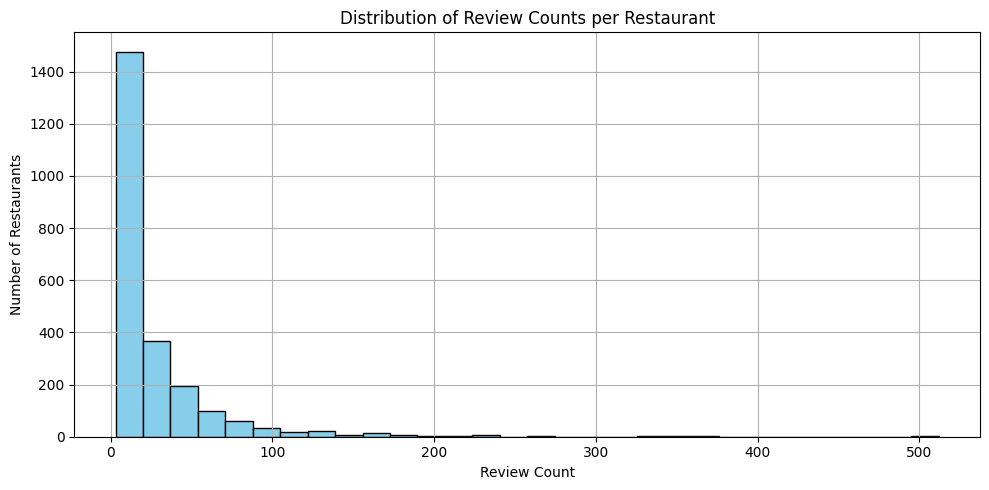

Q1 (25th percentile): 5.00
Median (50th percentile): 12.00
Q3 (75th percentile): 30.00
Mean: 25.01


In [ ]:
business_review_counts = (
    restaurant_df.groupby('business_id')['review_count'].first().reset_index()
) #selects the first occurrence of review_count from each business id

review_counts = business_review_counts['review_count']

#Plot
plt.figure(figsize=(10, 5))
plt.hist(review_counts, bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of Review Counts per Restaurant')
plt.xlabel('Review Count')
plt.ylabel('Number of Restaurants')
plt.grid(True)
plt.tight_layout()
plt.show()

#summary statistics
q1 = review_counts.quantile(0.25)
median = review_counts.median()
q3 = review_counts.quantile(0.75)
mean = review_counts.mean()
print(f"Q1 (25th percentile): {q1:.2f}")
print(f"Median (50th percentile): {median:.2f}")
print(f"Q3 (75th percentile): {q3:.2f}")
print(f"Mean: {mean:.2f}")

#Code source: (OpenAI, 2025d)

In [ ]:
valid_ids = business_review_counts[business_review_counts['review_count'] > 15]['business_id']
restaurant_df = restaurant_df[restaurant_df['business_id'].isin(valid_ids)] #filter restaurant with at least 15 reviews

# Group by the restaurant
restaurant_grouped = (
    restaurant_df.groupby('business_id')
    .agg({
        'name': 'first',
        'latitude': 'first',
        'longitude': 'first',
        'categories': 'first',
        'stars_y': 'mean',
        'review_count': 'first',
        'useful': 'sum',
        'funny': 'sum',
        'cool': 'sum',
        'text': lambda x: ' '.join(x)
    })
    .reset_index()
)

restaurant_grouped['polarity'] = restaurant_grouped['stars_y'].apply(lambda x: 1 if x > 3 else 0) # assign positive review label for star above 3

#Code source: (OpenAI, 2025q)

Most restaurants are concentrated in Calgary’s downtown area, which also hosts the majority of positively reviewed establishments. Additional clusters are observed along Macleod Trail and near the Horizon neighbourhood.

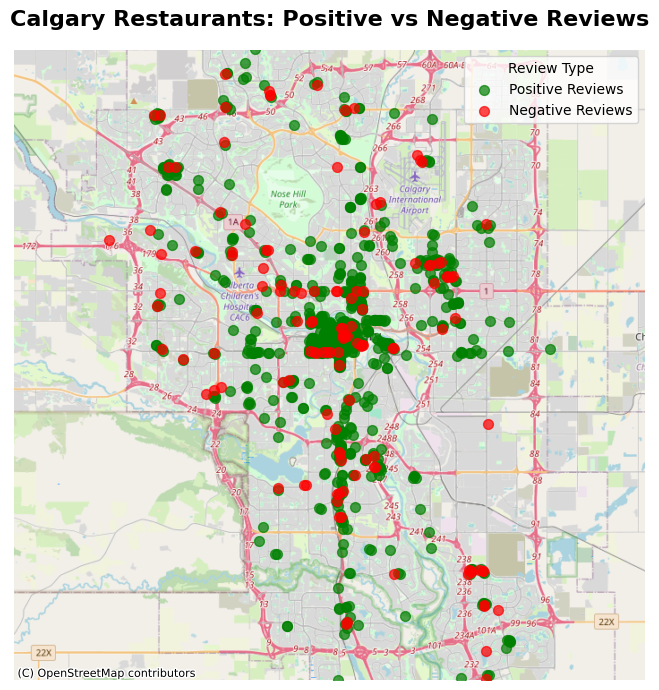

In [ ]:
geometry = [Point(lon, lat) for lon, lat in zip(restaurant_grouped['longitude'], restaurant_grouped['latitude'])] #converts the coordinates into point objects
gdf = gpd.GeoDataFrame(restaurant_grouped, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857) #convert to web mercator projection for open street map

# Map polarity labels
polarity_map = {1: 'Positive', 0: 'Negative'}
gdf['polarity_label'] = gdf['polarity'].map(polarity_map)

# Map bounds to make the map in clean square format
minx, miny, maxx, maxy = gdf.total_bounds
width = maxx - minx
height = maxy - miny
side = max(width, height)
center_x = (minx + maxx) / 2
center_y = (miny + maxy) / 2
minx_sq = center_x - side / 2
maxx_sq = center_x + side / 2
miny_sq = center_y - side / 2
maxy_sq = center_y + side / 2

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
gdf[gdf['polarity'] == 1].plot(ax=ax, color='green', markersize=50, alpha=0.7, label='Positive Reviews') #for positive reviews restaurants
gdf[gdf['polarity'] == 0].plot(ax=ax, color='red', markersize=50, alpha=0.7, label='Negative Reviews') #for negative reviews restaurants

ax.set_xlim(minx_sq, maxx_sq)
ax.set_ylim(miny_sq, maxy_sq)
ax.set_aspect('equal')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs)

ax.set_title("Calgary Restaurants: Positive vs Negative Reviews", fontsize=16, weight='bold')
ax.set_axis_off()
ax.legend(loc='upper right', fontsize=10, frameon=True, title='Review Type')
plt.tight_layout()
plt.show()

#Code source: (OpenAI, 2025k)

To inform the selection of potential sites for a new restaurant, the analysis examined customer reviews containing the phrase “great location.” This approach aimed to identify whether a restaurant’s location was perceived positively. Negative reviews were also included in this stage, based on the rationale that some poorly rated restaurants might still be situated in desirable locations, with the low ratings attributed to other factors such as service or food quality.

Next, the author examined keywords associated with place descriptions in reviews that mentioned a "great location." These keywords were categorized into three themes: natural features (e.g., river, park, hills), urban structures (e.g., city center, downtown, main street), and abstract qualities or ambiance (e.g., quiet, bustling, vibrant). This analysis aimed to better understand the specific spatial or experiential elements contributing to positive location-based reviews and the typical locations of such restaurants. A similar keyword-based approach was employed by Zhang et al. (2022) in their study on spatial perception in restaurant reviews.

The filtered text analysis yielded several frequently mentioned keywords. The top 15 terms included: park (42), view (24), mall (22), green (12), downtown (10), city (9), river (9), avenue (6), central (6), bustling (6), upscale (5), plaza (4), modern (4), hill (4), and nearby (3). Based on the prominence of these keywords, combined with the spatial clustering of positively and negatively reviewed restaurants, Crescent Heights, located just north of downtown, was identified as a promising location for a new restaurant development.

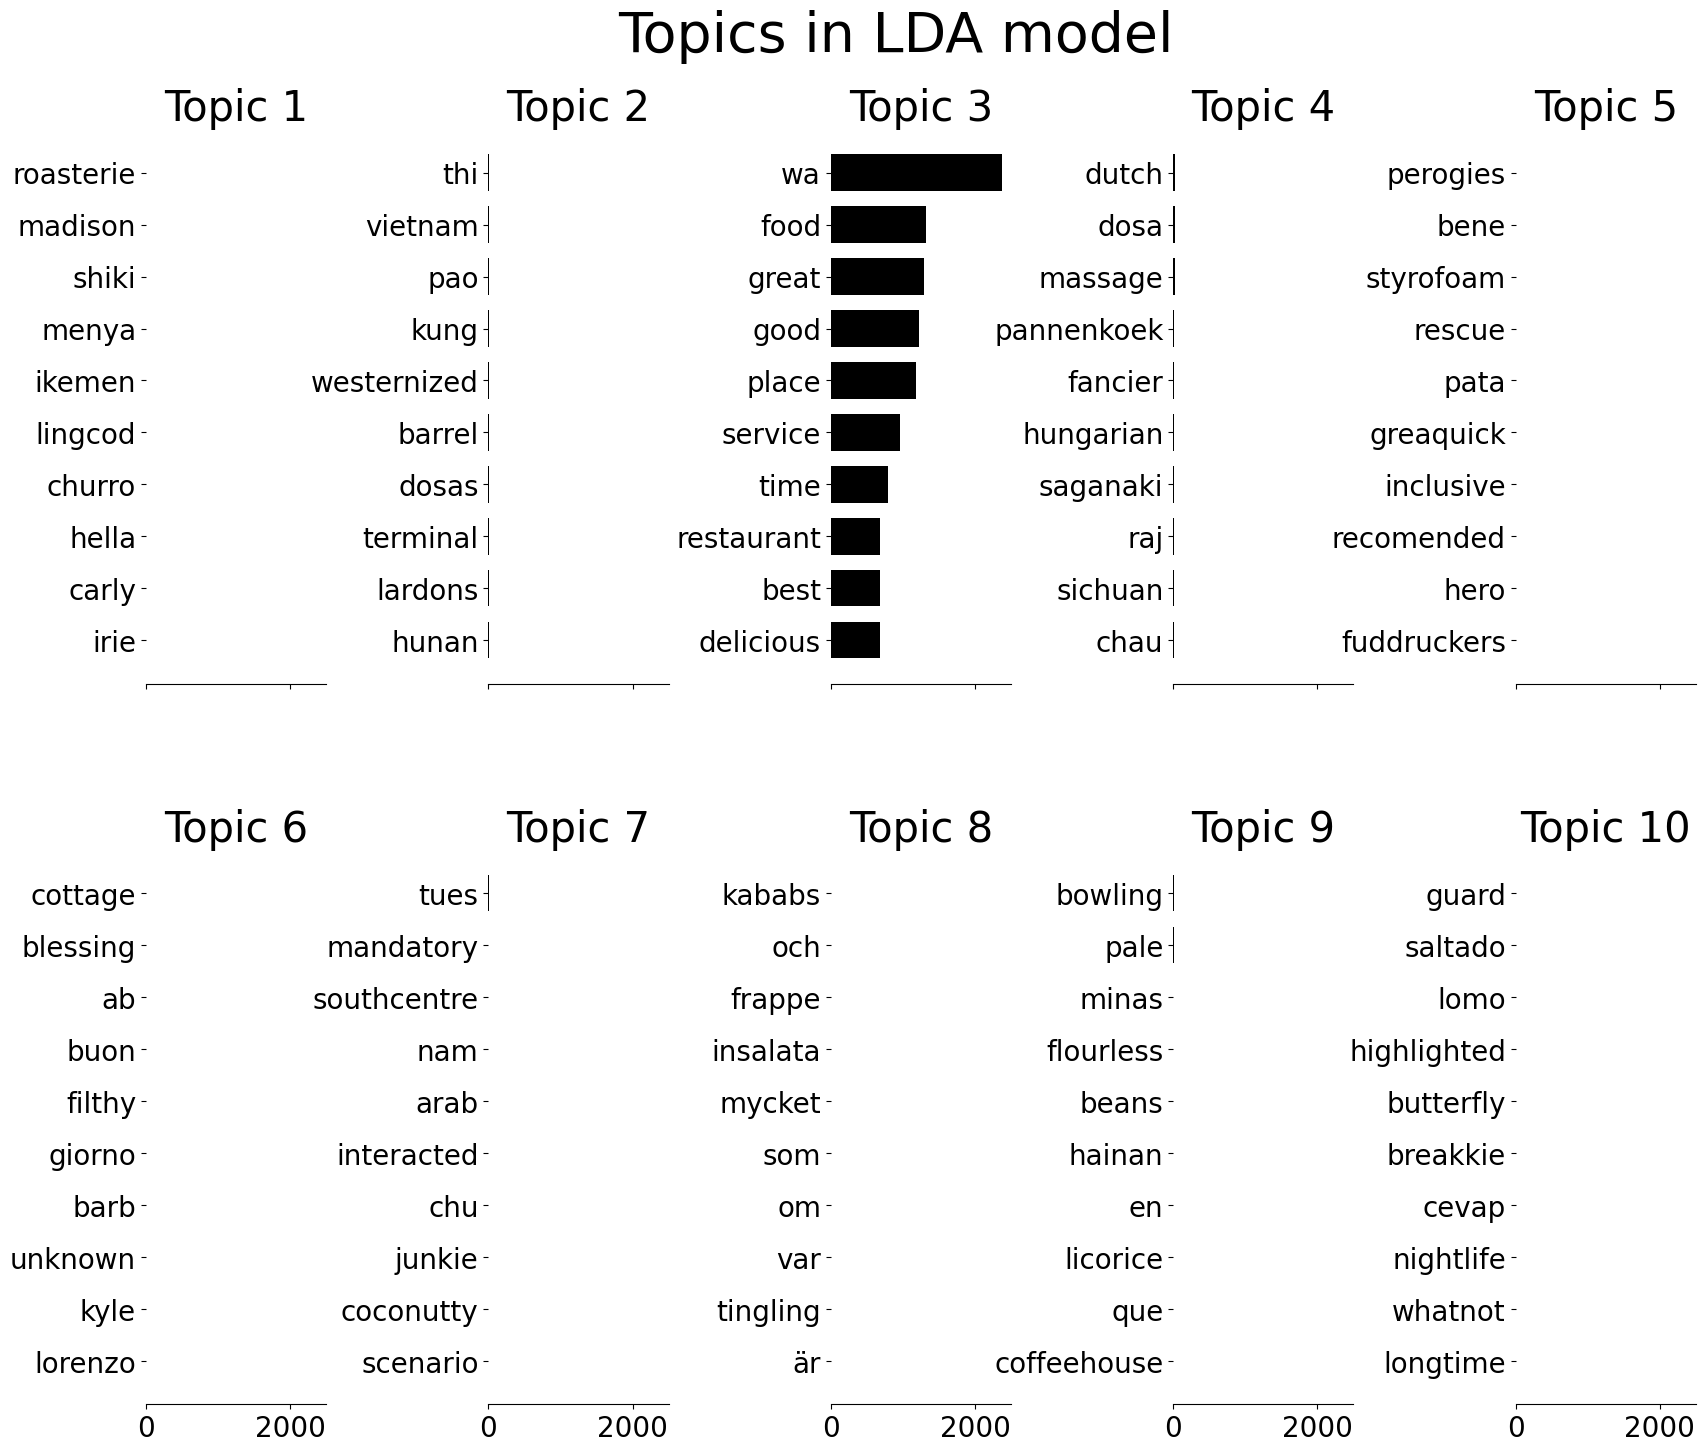

In [ ]:
#Topic Modelling
def plot_top_words(model, feature_names, n_top_words, title, rows=2, columns=5): # visualize the top words for each topic
    fig, axes = plt.subplots(rows, columns, figsize=(20, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7,color='black')
        ax.set_title(f'Topic {topic_idx +1}',
                     fontdict={'fontsize': 30})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=20)
        for i in 'top right left'.split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

corpus_text = restaurant_df[restaurant_df['polarity'] == 1]['cleaned_text'].tolist() #convert cleaned review text into list
vectorizer_text = TfidfVectorizer(lowercase=True, stop_words='english', min_df=2, max_df=0.95) #turns the text into numerical vectors with TF-IDF vectorizer (make every words into lowecase, remove stop words, and remove very common and rare words)
X_text = vectorizer_text.fit_transform(corpus_text) #fit the cleaned text with the TF-IDF vectorizer
tf_feature_names = vectorizer_text.get_feature_names_out()


no_topics=10
lda = LatentDirichletAllocation(no_topics, max_iter=10, learning_method='online', learning_offset=50.,random_state=0).fit(X_text)

no_top_words = 10
plot_top_words(lda, tf_feature_names, no_top_words, 'Topics in LDA model')

#Code source: (Law et al., 2025c)

In [ ]:
# Define keywords to search for
keywords = [
    'view', 'river', 'park', 'city center', 'downtown', 'mall', 'lake',
    'green', 'nature', 'city', 'hills', 'airport', 'scenery', 'vibrant', 'buildings',
    'landmark', 'walkable', 'near transit', 'central', 'quiet', 'bustling', 'historic',
    'accessible', 'safe', 'neighborhood', 'rooftop', 'plaza', 'harbor', 'bay', 'boardwalk',
    'intersection', 'main street', 'corner', 'atrium', 'square', 'waterfront', 'sunset', 'city lights', 'car park', 'view', 'sunset', 'sunrise', 'river', 'lake', 'park', 'green', 'nature',
    'scenery', 'waterfront', 'mountains', 'beach', 'hill', 'valley', 'harbor', 'bay',
    'view', 'sunset', 'sunrise', 'river', 'lake', 'park', 'green', 'nature',
    'scenery', 'waterfront', 'mountains', 'beach', 'hill', 'valley', 'harbor', 'bay',
    'city center', 'downtown', 'skyline', 'buildings', 'rooftop', 'atrium',
    'plaza', 'square', 'main street', 'intersection', 'corner', 'avenue', 'boulevard', 'historic',
    'near transit', 'central', 'walkable', 'accessible', 'connected', 'transit hub', 'public transport',
    'close by', 'nearby', 'short walk', 'easy access',
    'mall', 'landmark', 'monument', 'museum', 'gallery', 'airport', 'station', 'university', 'stadium',
    'quiet', 'bustling', 'vibrant', 'lively', 'charming', 'peaceful', 'upscale', 'trendy', 'modern', 'picturesque',
    'neighborhood', 'district', 'suburb', 'residential', 'downtown core', 'financial district', 'entertainment district'
]

# Create a keyword tag column
def extract_keywords(text):
    if pd.isnull(text): return "" #if the text is missing, return blank
    text = text.lower() #make the text lowercased
    return ", ".join([kw for kw in keywords if kw in text]) #returns a comma-separated string

restaurant_df['_positive_landmark_mentions'] = "" #creates a new empty column

positive_mask = restaurant_df['polarity'] == 1
location_mask = restaurant_df['cleaned_text'].str.contains(r'\bgreat location\b', case=False, na=False)
mask = positive_mask & location_mask
restaurant_df.loc[mask, '_positive_landmark_mentions'] = restaurant_df.loc[mask, 'cleaned_text'].apply(extract_keywords) #apply the function of extract_keywords on every cleaned text and store it in

# Join all keywords into one big list
all_mentions = restaurant_df.loc[restaurant_df['polarity'] == 1, '_positive_landmark_mentions']
all_keywords = [kw.strip() for entry in all_mentions if entry for kw in entry.split(',')]
keyword_counts = Counter(all_keywords)

print(keyword_counts)

#Code source: (OpenAI, 2025g)

Counter({'park': 42, 'view': 24, 'mall': 22, 'green': 12, 'downtown': 10, 'city': 9, 'river': 9, 'avenue': 6, 'central': 6, 'bustling': 6, 'upscale': 5, 'plaza': 4, 'modern': 4, 'hill': 4, 'nearby': 3, 'trendy': 3, 'nature': 3, 'lake': 3, 'beach': 2, 'quiet': 2, 'accessible': 2, 'neighborhood': 2, 'historic': 2, 'stadium': 1, 'district': 1, 'short walk': 1, 'safe': 1})


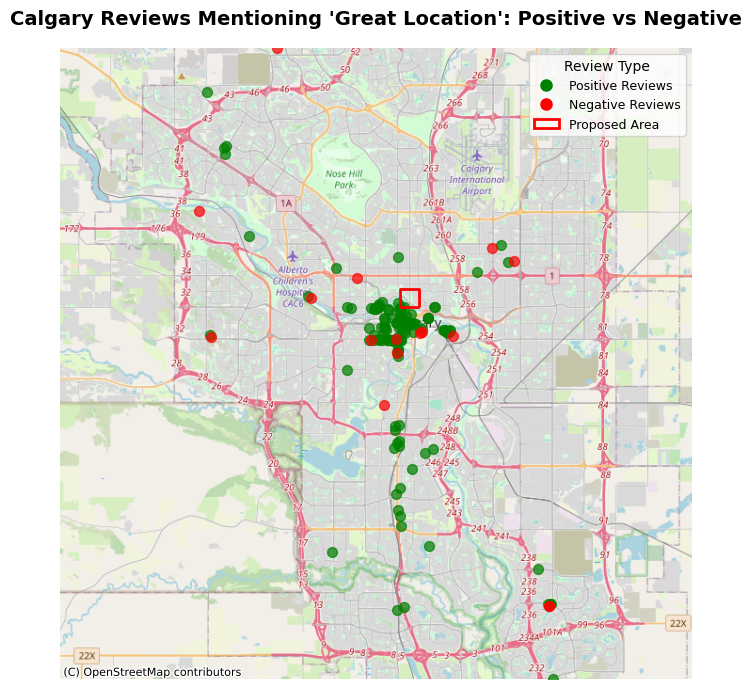

In [ ]:
location_mask = gdf['text'].str.contains(r'\bgreat location\b', case=False, na=False) #specifically filter reviews that mentioned "great location" in order to find suitability for new restaurant location
gdf_location = gdf[location_mask].copy()
gdf_location = gdf_location.to_crs(epsg=3857)  #convert to web mercator projection for open street map

# Map polarity labels
gdf_location['polarity_label'] = gdf_location['polarity'].map({1: 'Positive', 0: 'Negative'})

# Define red box (proposed site) in Web Mercator
proposed_center = gpd.GeoSeries([box(-114.07, 51.053, -114.056, 51.061)], crs="EPSG:4326").to_crs(epsg=3857) #create bbox with crs 4326 originally and convert it to web mercator projection for openstreet map suitability
red_box = proposed_center.geometry[0] #accesses the actual Polygon geometry
red_box_gdf = gpd.GeoDataFrame(geometry=[red_box], crs="EPSG:3857") #wraps the polygon in a GeoDataFrame

# Map bounds to make the map in clean square format
minx, miny, maxx, maxy = gdf_location.total_bounds
width, height = maxx - minx, maxy - miny
side = max(width, height)
center_x = (minx + maxx) / 2
center_y = (miny + maxy) / 2
minx_sq, maxx_sq = center_x - side / 2, center_x + side / 2
miny_sq, maxy_sq = center_y - side / 2, center_y + side / 2

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

pos = gdf_location[gdf_location['polarity'] == 1]
neg = gdf_location[gdf_location['polarity'] == 0]
ax.scatter(pos.geometry.x, pos.geometry.y, color='green', s=50, alpha=0.7, label='Positive Reviews') #for positive reviews restaurants
ax.scatter(neg.geometry.x, neg.geometry.y, color='red', s=50, alpha=0.7, label='Negative Reviews') #for negative reviews restaurants

ax.set_xlim(minx_sq, maxx_sq)
ax.set_ylim(miny_sq, maxy_sq)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf_location.crs)

red_box_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# Legend
green_circle = mlines.Line2D([], [], color='green', marker='o', linestyle='None',
                             markersize=8, label='Positive Reviews')
red_circle = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                           markersize=8, label='Negative Reviews')
box_patch = mpatches.Patch(facecolor='none', edgecolor='red', linewidth=2, label='Proposed Area')

ax.set_title("Calgary Reviews Mentioning 'Great Location': Positive vs Negative", fontsize=14, weight='bold')
ax.set_axis_off()
ax.legend(handles=[green_circle, red_circle, box_patch], loc='upper right', fontsize=9, frameon=True, title='Review Type')

plt.tight_layout()
plt.show()

# Code source: (OpenAI, 2025n)

High-performing restaurants often cluster near one another due to imitation behaviors and the perceived quality spillover from well-established competitors (Sun & Paule, 2017; Motoyama & Usher, 2020; Hotelling, 1929; Mossay, Shin, & Smrkolj, 2020). However, differentiation remains critical, particularly in terms of location, to establish a unique market position (Miller & Friesen, 1986; Leonardi & Moretti, 2023). For these reasons, the selected area in this study is situated near existing clusters of positively rated restaurants to benefit from quality spillover, while remaining sufficiently distant to retain spatial distinction from direct competitors.

The proposed location for the new restaurant is at coordinates -114.063306, 51.056972, situated on Crescent Road NW. This site is considered highly suitable due to its proximity to features frequently associated with the phrase “great location” in user reviews. Notably, it is near parks such as Sunny Bank Park and Rotary Park, the Bow River, and elevated terrain in Crescent Heights. The location provides access to green spaces and panoramic views of both natural and urban landscapes, while remaining close to the city center. Additionally, this location lies near a road segment with the highest betweenness centrality in the area, indicating strong accessibility and integration within the city’s street network.

In [ ]:
G=ox.graph_from_address('Downtown, Calgary', dist=2000, network_type='drive') #download the walking network around Green End Road, Cambridge within 2 km radius
DG = ox.convert.to_digraph(G) #convert into directed graph
edge_bc=nx.betweenness_centrality(nx.line_graph(DG)) #calculates betweeness centrality
nx.set_edge_attributes(DG,edge_bc,'bc') #calculate betweeness centrality for every edges
G1 = nx.MultiGraph(DG)  #convert into multi graph

#Code source: (Law et al., 2025a)

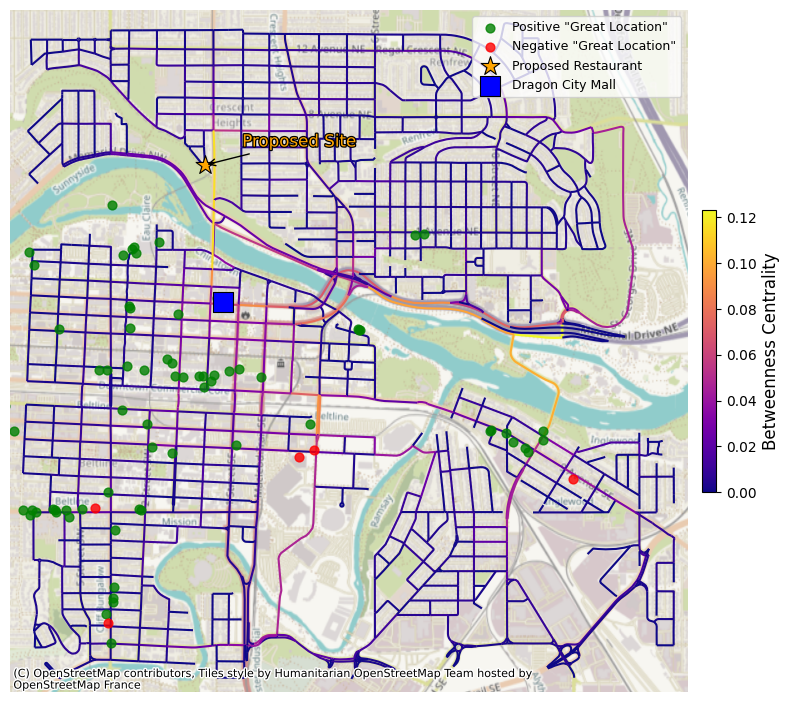

In [ ]:
attr = 'bc'
cmap = 'plasma'
nc = ox.plot.get_edge_colors_by_attr(G1, attr, cmap=cmap) #displaying color for betweeness centrality levels

fig, ax = ox.plot_graph(G1,
                        node_size=0,
                        node_color='w',
                        node_edgecolor='gray',
                        node_zorder=2,
                        edge_color=nc,
                        edge_linewidth=1.5,
                        edge_alpha=1,
                        show=False,
                        close=False)

# Add Basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.HOT, crs='EPSG:4326')

#Plot Reviews Mentioning "great location"
gdf_location = gdf[gdf['text'].str.contains(r'\bgreat location\b', case=False, na=False)].copy()
gdf_location['polarity_label'] = gdf_location['polarity'].map({1: 'Positive', 0: 'Negative'})
gdf_location = gdf_location.to_crs("EPSG:4326")

gdf_location[gdf_location['polarity'] == 1].plot(
    ax=ax, color='green', markersize=40, alpha=0.8, label='Positive "Great Location"'
)
gdf_location[gdf_location['polarity'] == 0].plot(
    ax=ax, color='red', markersize=40, alpha=0.8, label='Negative "Great Location"'
)

#Add Proposed Restaurant Point
proposed_point = gpd.GeoDataFrame(
    geometry=[Point(-114.063306, 51.056972)],
    crs="EPSG:4326"
)

mall = gpd.GeoDataFrame(
    geometry=[Point(-114.0617, 51.0494)],
    crs="EPSG:4326"
)

proposed_point.plot(
    ax=ax, color='orange',edgecolor='black',linewidth=0.8, marker='*', markersize=200, label='Proposed Restaurant'
)

mall.plot(
    ax=ax, color='blue',edgecolor='black',linewidth=0.8, marker='s', markersize=200, label='Dragon City Mall'
)
#annotation
text = ax.annotate(
    "Proposed Site",
    xy=(-114.063306, 51.056972),
    xytext=(-114.06, 51.058),
    arrowprops=dict(arrowstyle="->", color='black'),
    fontsize=12,
    color='orange'
)

text.set_path_effects([
    path_effects.Stroke(linewidth=1.8, foreground='black'),
    path_effects.Normal()
])

# --- 7. Add Colorbar for Betweenness ---
sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(
    vmin=min(edge_bc.values()),
    vmax=max(edge_bc.values()))) #Normalize the data values to the 0-1 range based on the minimum and maximum values
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Betweenness Centrality', fontsize=12)


ax.set_axis_off()
ax.legend(loc='upper right', fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

#Code source: (Law et al., 2025a; OpenAI, 2025a)

### Conclusion

This study demonstrates the potential of using supervised machine learning models to predict the score of a place from user-generated text and how those user-generated text can be a powerful insight to build new amenities .

However, this research has limitations. For instance, the machine learning component could be extended by comparing additional models such as Support Vector Machines (Suryaningrum, 2023; Shihab et al., 2018) or even advanced model such BERT-based classifiers (Bilal & Almazroi, 2022) to assess performance on similar datasets.

In terms of determining restaurant location analysis, there are several important factors remain unaddressed in this study. For example, in Calgary, new restaurant developments must comply with zoning regulations outlined in the Calgary Land Use Bylaw 1P2007 (City of Calgary, 2025), which future research should incorporate. Additionally, public concerns, such as noise impacts in residential areas (Calgary, 2023; Brehaut, 2023) and issues related to gentrification and displacement following restaurant openings (Glaeser, Kim, & Luca, 2018), should also be considered when evaluating potential sites. Overall, This study serves as an initial exploration, with the aim of informing and encouraging further research in the fields of human mobility and text-based spatial analysis.











Reference list

Akrivia Health (2022). What is Natural Language Processing (NLP)? Akrivia Health.

Andrienko, N.V., Andrienko, G.L. and Fuchs, G. (2013). Towards Privacy-Preserving Semantic Mobility Analysis. EuroVis. doi:https://doi.org/10.2312/pe.eurovast.eurova13.019-023.

Bai, X., Xie, Z., Xu, X. and Xiao, Y. (2023). An adaptive threshold fast DBSCAN algorithm with preserved trajectory feature points for vessel trajectory clustering. Ocean Engineering, 280. doi:https://doi.org/10.1016/j.oceaneng.2023.114930.

Bilal, M. and Almazroi, A.A. (2022). Effectiveness of Fine-tuned BERT Model in Classification of Helpful and Unhelpful Online Customer Reviews. Electronic Commerce Research, 23, pp.2737–2757. doi:https://doi.org/10.1007/s10660-022-09560-w.

Brehaut, L. (2023). You’re not wrong: Canadian restaurants really are getting louder. [online] National Post. Available at: https://nationalpost.com/life/food/soundprint-canada-noisy-restaurants-too-loud.

Brown, H. (2025). Community hub at Cambridge development will ‘enrich local life’. [online] Cambridgeshire Live. Available at: https://www.cambridge-news.co.uk/news/cambridge-news/community-hub-cambridge-development-enrich-30904804 [Accessed 1 May 2025].

Buhl, N. (2023). F1 Score in Machine Learning. [online] encord.com. Available at: https://encord.com/blog/f1-score-in-machine-learning/.

Calgary (2023). Noise on residential properties. [online] Calgary. Available at: https://www.calgary.ca/bylaws/residential-noise.html [Accessed 14 Oct. 2023].

Calgary (2025). Calgary Land Use Bylaw 1P2007. [online] Calgary. Available at: https://www.calgary.ca/planning/land-use.html.

Cambridge City Council (2019). Indices of multiple deprivation 2019 report. Cambridge City Council.

Cambridge City Council (2025). Map of parks and playgrounds. [online] Cambridge City Council. Available at: https://www.cambridge.gov.uk/map-of-parks-and-playgrounds [Accessed 1 May 2025].

Carvalho, A.M., Ferreira, M.C. and Dias, T.G. (2021). Understanding mobility patterns and user activities from geo-tagged social networks data. Transportation Research Procedia, 52, pp.493–500. doi:https://doi.org/10.1016/j.trpro.2021.01.058.

Chen, X., Pei, T., Song, C., Shu, H., Guo, S., Wang, X., Liu, Y. and Chen, J. (2024). Coupling human mobility and social relationships to predict individual socioeconomic status: A graph neural network approach. Transactions in GIS, 28(5). doi:https://doi.org/10.1111/tgis.13189.

Cohen, M., Burrowes, K. and Gwam, P. (2022). The Health Benefits of Parks and their Economic Impacts: A Review of the Literature. Urban Institute.

Douglas, D.H. and Peucker, T.K. (1973). ALGORITHMS FOR THE REDUCTION OF THE NUMBER OF POINTS REQUIRED TO REPRESENT A DIGITIZED LINE OR ITS CARICATURE. Cartographica: The International Journal for Geographic Information and Geovisualization, 10(2), pp.112–122. doi:https://doi.org/10.3138/fm57-6770-u75u-7727.

Friends of the Earth (2020). England’s green space gap: How to end green space deprivation in England. Friends of the Earth.

Gao, H. and Liu, H. (2015). Mining Human Mobility in Location-Based Social Networks. Morgan & Claypool Publishers.

GeeksfoGeeks (2023). Multinomial Naive Bayes. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/multinomial-naive-bayes/.

Glaeser, E.L., Kim, H. and Luca, M. (2018). Nowcasting Gentrification: Using Yelp Data to Quantify Neighborhood Change. AEA Papers and Proceedings, 108, pp.77–82. doi:https://doi.org/10.2139/ssrn.3123733.

Greater Cambridge Planning Service (2021). North East Cambridge Area Action Plan Proposed Submission. Greater Cambridge Planning Service.

Gyurkovich, K.D. (2023). Study of Centrality Measures in the Network of Green Spaces in the City of Krakow. Sustainability, 15(18). doi:https://doi.org/10.3390/su151813458.

Haq, B., Khan, S., Umer, R. and Uddin, N. (2022). Machine Learning Algorithms for Predicting the Impact of Business Attributes Over Business Stars of Yelp Data-Set. International Review of Basic and Applied Sciences, 10(2).

Hotelling, H. (1929). Stability in Competition. The Economic Journal, 39(153), pp.41–57.

Hu, Y. (2018). Geo-text data and data-driven geospatial semantics. Geography Compass, 12(11). doi:https://doi.org/10.1111/gec3.12404.

Krishnamurthy, P. and Pelechrinis, K. (2013). Location-Based Social Networks  . In: Advanced Location-Based Technologies and Services. Taylor & Francis.

Law, S., Neira, M., Tanu, N., Keel, T., Jie, G., Tang, J. and Hu, D. (2025a). GEOG0051 Computer Lab 3: NetworkX and OSMnx. UCL Department of Geography.

Law, S., Neira, M., Tanu, N., Keel, T., Jie, G., Tang, J. and Hu, D. (2025b). Lab Notebook 6: Introduction to Human Mobility Analysis. UCL Department of Geography.

Law, S., Neira, M., Tanu, N., Keel, T., Jie, G., Tang, J. and Hu, D. (2025c). Lab Notebook 7.1: Introduction to Text Analysis. UCL Department of Geography.

Law, S., Neira, M., Tanu, N., Keel, T., Jie, G., Tang, J. and Hu, D. (2025d). Lab Notebook 7.1: Machine Learning for travel mode prediction (tabular data). UCL Department of Geography.

Le, J.P. (2022). Rating Prediction from Review Text with Regularization — Linear Regression vs Logistic Regression. [online] Medium. Available at: https://medium.com/mitb-for-all/rating-prediction-from-review-text-with-regularization-linear-regression-vs-logistic-regression-df0181fe9c07.

Leonardi, M. and Moretti, E. (2023). The Agglomeration of Urban Amenities: Evidence from Milan Restaurants. American Economic Review: Insights, 5(2), pp.141–157. doi:https://doi.org/10.1257/aeri.20220011.

Martín, Y., Cutter, S.L., Li, Z., Emrich, C.T. and Mitchell, J.T. (2020). Using geotagged tweets to track population movements to and from Puerto Rico after Hurricane Maria. Population and Environment, 42(1), pp.4–27. doi:https://doi.org/10.1007/s11111-020-00338-6.

Mathew, J., Kshirsagar, R., Abidin, D.Z., Griffin, J., Kanarachos, S., James, J., Alamaniotis, M. and Fitzpatrick, M.E. (2023). A comparison of machine learning methods to classify radioactive elements using prompt-gamma-ray neutron activation data. Scientific Reports, 13(1). doi:https://doi.org/10.21203/rs.3.rs-2518432/v1.

Mattos, E.P. de , Domingues, A.C.S.A., Santos, B.P., Ramos, H.S. and Loureiro, A.A.F. (2022). The Impact of Mobility on Location Privacy: A Perspective on Smart Mobility. IEEE Systems Journal, 16(4), pp.5509–5520. doi:https://doi.org/10.1109/jsyst.2022.3147808.

Miller, D. and Friesen, P.H. (1986). Porter’s (1980) Generic Strategies and Performance: An Empirical Examination with American Data. Organization Studies, 7(3), pp.255–261. doi:https://doi.org/10.1177/017084068600700303.

Monett, D. and Stolte, H. (2016). Predicting Star Ratings based on Annotated Reviews of Mobile Apps. Annals of Computer Science and Information Systems, 8, pp.421–428. doi:https://doi.org/10.15439/2016f141.

Moore, A., Boyle, B. and Lynch, H. (2022). Designing for Inclusion in Public playgrounds: a Scoping Review of definitions, and Utilization of Universal Design. Disability and Rehabilitation. Assistive Technology, 18(8), pp.1453–1465. doi:https://doi.org/10.1080/17483107.2021.2022788.

Moses, S. and Westermann, M. (2017). DBSCAN: Density-Based Spatial Clustering of Applications with Noise. [online] GitHub. Available at: https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/cluster/_dbscan.py [Accessed 2 May 2025].

Mossay, P., Shin, J.K. and Smrkolj, G. (2020). Quality Differentiation and Spatial Clustering among Restaurants. Munich Personal RePEc Archive.

Motoyama, Y. and Usher, K. (2020). Restaurant Reviews and Neighborhood Effects. Papers in Applied Geography, 6(4), pp.386–401. doi:https://doi.org/10.1080/23754931.2020.1791942.

Ojeda-Revah, L., Bojorquez, I. and Osuna, J.C. (2017). How the legal framework for urban parks design affects user satisfaction in a Latin American city. Cities, 69, pp.12–19. doi:https://doi.org/10.1016/j.cities.2017.05.016.

OpenAI (2025a). and I want to add this ‘51°03’25.1"N 114°03’47.9"W’ specific point as my proposed location for the new restaurant. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/680abdc8-df9c-800a-8016-4f55f7dfaac5 [Accessed 1 May 2025].

OpenAI (2025b). can you change the opacity of this code "# Read GeoJSON (spatial file) geojson_path = os.path.join(base_path, ‘WD_MAY_2023_UK_BFC_-6713663680658858762.geojson’) gdf = gpd.read_file(geojson_path). [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

OpenAI (2025c). can you fix this code "fig, axes = plt.subplots(2, 3, figsize=(15, 4)) sns.heatmap(cm_lr, annot=True, fmt=‘d’, cmap=‘Blues’, cbar=False, xticklabels=[‘Negative’, ‘Positive’], yticklabels=[‘Negative’, ‘Positive’], ax=axes[0]). [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/680abdc8-df9c-800a-8016-4f55f7dfaac5 [Accessed 1 May 2025].

OpenAI (2025d). can you improve my code ‘df[“polarity”] = df[“stars_y”].apply(lambda x: “Positive” if x >= 4 else “Negative”) # Only restaurants with positive reviews restaurant_df = df[df[“categories”].str.contains(r’Restaurants|Food’, case=False, na=False) &(df[“polarity”] == 1)]restaurant_df = restaurant_df.dropna(subset=[“latitude”, “longitude”]) geometry = [Point(xy) for xy in zip(restaurant_df[“longitude”], restaurant_df[“latitude”])] gdf = gpd.GeoDataFrame(restaurant_df, geometry=geometry, crs=“EPSG:4326”)  gdf = gdf.to_crs(epsg=3857)’. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/681068c5-800c-800a-9b55-5c5bbfd160e6 [Accessed 1 May 2025].

OpenAI (2025e). do i need to change these format "0   ID       1871 non-null   int64  1   User_ID  1871 non-null   int64  2   date     1871 non-null   object 3   Time     1871 non-null   object 4   lon      1871 non-null   float645   lat      1871 non-null   float646   loc_ID   1871 non-null   int64 "? [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448?src=history_search [Accessed 1 May 2025].

OpenAI (2025f). from this code "user1_df = trajectories[102829].df.reset_index() user1_day_df = user1_df[user1_df[‘date_time’].dt.date == pd.to_datetime(‘2010-05-25’).date()] traj_day = mpd.Trajectory(user1_day_df, 102829, t=‘date_time’, x=‘lon’, y=‘lat’) traj_day.hvplot()", i got this result. Now I want to create trajectory line like this for all of the dates (where the dates have more than 1 point) and I want the begining of the point of each day to be circle and the end point of each day will be an arrow. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448?src=history_search [Accessed 1 May 2025].

OpenAI (2025g). from this data "MbZMmwo-eL0Jnm_Yb9KJrA	Chinook Landscaping and Design	50.9459599	-114.0372072	3	Contractors, Landscaping, Home Services	{‘Monday’: ’7:0-17:0’, ‘Tuesday’: ’7:0-17:0’, ‘Wednesday’: ’7:0-17:0’, ‘Thursday’: ’7:0-17:0’, ‘Friday’: ’7:0-17:0’, ‘Saturday’: ’7:0-17:0’}	pltqT0DnejbWN-K32BD1Fg. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/681068c5-800c-800a-9b55-5c5bbfd160e6 [Accessed 1 May 2025].

OpenAI (2025h). from this data "MbZMmwo-eL0Jnm_Yb9KJrA	Chinook Landscaping and Design	50.9459599	-114.0372072	3	Contractors, Landscaping, Home Services	{‘Monday’: ’7:0-17:0’, ‘Tuesday’: ’7:0-17:0’, ‘Wednesday’: ’7:0-17:0’, ‘Thursday’: ’7:0-17:0’, ‘Friday’: ’7:0-17:0’, ‘Saturday’: ’7:0-17:0’} pltqT0DnejbWN-K32BD1Fg. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/681068c5-800c-800a-9b55-5c5bbfd160e6 [Accessed 1 May 2025].

OpenAI (2025i). how to change the visualisation of "G=ox.graph_from_address(‘Green End Road, Cambridge’, dist=1000, network_type=‘walk’) DG = ox.convert.to_digraph(G). [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

OpenAI (2025j). how to change this "traj_collection = mpd.TrajectoryCollection(cambridge_df, ‘user’, t=‘date_time’, x=‘longitude’, y=‘latitude’) " into each individual users of  User IDs [75027] and [102829]. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448?src=history_search [Accessed 1 May 2025].

OpenAI (2025k). I have changed the figsize to 8,8 but the image is still looking like this. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/680abdc8-df9c-800a-8016-4f55f7dfaac5 [Accessed 1 May 2025].

OpenAI (2025l). I havent had ‘Assuming you have a list of shortest paths between consecutive points already stored’. I just executed the code like this. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

OpenAI (2025m). I want to add these as consideration as well review_count , useful,	funny, and	cool. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/681068c5-800c-800a-9b55-5c5bbfd160e6 [Accessed 1 May 2025].

OpenAI (2025n). I want to create like this "import matplotlib.pyplot as plt import contextily as ctx # Ensure polarity is numeric: 1 (Positive), 0 (Negative) polarity_map = {1: ‘Positive’, 0: ‘Negative’} gdf[‘polarity_label’] = gdf[‘polarity’].map(polarity_map). [online] ChatGPT (May 1, 2025 Version). Available at: https://colab.research.google.com/drive/1mWxtniruPxsGET1oAuEHyU4DDeXKy58I?authuser=2#scrollTo=BFCXSMFNHHM4 [Accessed 1 May 2025].

OpenAI (2025o). it turns out that there are points cluster together, what if I removed them and only represent one point for each clusters so that the path will be more smoother? [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

OpenAI (2025p). okay change of plan again, I want to show king’s hedges like this but also the street network and community park that is surrounding king’s hedges (around 10km radius). [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

OpenAI (2025q). the review count is something like this "business_id	name	latitude	longitude	review_count	categories	hours	review_id	user_id	stars_y	useful	funny	cool	text	date MbZMmwo-eL0Jnm_Yb9KJrA	Chinook Landscaping and Design	50.9459599	-114.0372072	3	Contractors, Landscaping, Home Services. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/681068c5-800c-800a-9b55-5c5bbfd160e6 [Accessed 1 May 2025].

OpenAI (2025r). the ward name in geojson file is WD23NM and the ward name in the csv file is Wards. [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

OpenAI (2025s). this code works "# Step 1: Load full graph G = ox.graph_from_place(‘Cambridgeshire, UK’, network_type=‘drive’). [online] ChatGPT (May 1, 2025 Version). Available at: https://chatgpt.com/c/6808c030-1f70-800a-8495-d3a5bb7df448 [Accessed 1 May 2025].

Pellungrini, R., Pappalardo, L., Pratesi, F. and Monreale, A. (2018). Analyzing privacy risk in human mobility data. Software Technologies: Applications and Foundations: STAF 2018 Collocated Workshops, Toulouse, France, June 25-29, 2018, Revised Selected Papers , pp.114–129.

Rahimi, S., Mottahedi, S. and Liu, X. (2018). The Geography of Taste: Using Yelp to Study Urban Culture. ISPRS International Journal of Geo-Information, [online] 7(9). doi:https://doi.org/10.3390/ijgi7090376.

Rakhmanov, O. (2020). A Comparative Study on Vectorization and Classification Techniques in Sentiment Analysis to Classify Student-Lecturer Comments. Procedia Computer Science, 178, pp.194–204. doi:https://doi.org/10.1016/j.procs.2020.11.021.

Reddy, Ch.S.C., Kumar, K.U., Keshav, J.D., Prasad, B.R. and Agarwal, S. (2017). Prediction of star ratings from online reviews. TENCON 2017 - 2017 IEEE Region 10 Conference. doi:https://doi.org/10.1109/tencon.2017.8228161.

Shihab, I.F., Oishi, M.M., Islam, S., Banik, K. and Arif, H. (2018). A Machine Learning Approach to Suggest Ideal Geographical Location for New Restaurant Establishment. In: IEEE Xplore. pp.1–5. doi:https://doi.org/10.1109/R10-HTC.2018.8629845.

Sun, Y. (2022). Prediction of Yelp Score from Reviewswith Machine Learning Model. University of California, Los Angeles.

Sun, Y. and Paule, J.D.G. (2017). Spatial analysis of users-generated ratings of yelp venues. Open Geospatial Data, Software and Standards, 2(1). doi:https://doi.org/10.1186/s40965-017-0020-9.

Suryaningrum, K.M. (2023). Comparison of the TF-IDF Method with the Count Vectorizer to Classify Hate Speech. Engineering, Mathematics and Computer Science Journal (EMACS), 5(2), pp.79–83. doi:https://doi.org/10.21512/emacsjournal.v5i2.9978.

Tayeen, A.S.Md., Mtibaa, A. and Misra, S. (2019). Location, Location, Location! Quantifying the True Impact of Location on Business Reviews Using a Yelp Dataset. In: 9 IEEE/ACM International Conference on Advances in Social Networks Analysis and Mining.

Terroso-Saenz, F., Flores, R. and Muñoz, A. (2022). Human mobility forecasting with region-based flows and geotagged Twitter data. Expert Systems with Applications, 203. doi:https://doi.org/10.1016/j.eswa.2022.117477.

Wang, X., Liu, H., Wang, P., Wu, F., Xu, H., Wang, W. and Xie, X. (2019). Neural review rating prediction with hierarchical attentions and latent factors. In: Database Systems for Advanced Applications: DASFAA 2019 International Workshops: BDMS, BDQM, and GDMA. Springer International Publishing, pp.363–367.

Xu, S., Li, Y. and Wang, Z. (2017). Bayesian Multinomial Naïve Bayes Classifier to Text Classification. Lecture Notes in Electrical Engineering, pp.347–352. doi:https://doi.org/10.1007/978-981-10-5041-1_57.

Yang, M. and Luo, S. (2021). Effects of Rural Restaurants’ Outdoor Dining Environment Dimensions on Customers’ Satisfaction: A Consumer Perspective. Foods, 10(9). doi:https://doi.org/10.3390/foods10092172.

Yiliu, W., Hussain, N. and Shukor, S.F.A. (2025). Safety perceptions related to park environments: a scoping review. World Leisure Journal. doi:https://doi.org/10.1080/16078055.2025.2469778.

Yin, G., Liu, T., Chen, Y. and Hou, Y. (2022). Disparity and Spatial Heterogeneity of the Correlation between Street Centrality and Land Use Intensity in Jinan, China. International Journal of Environmental Research and Public Health, 19(23). doi:https://doi.org/10.3390/ijerph192315558.

Zhang, J., Li, X., Yao, Y., Hong, Y., He, J., Jiang, Z. and Sun, J. (2021). The Traj2Vec model to quantify residents’ spatial trajectories and estimate the proportions of urban land-use types. International Journal of Geographical Information Science, 35(1), pp.193–211. doi:https://doi.org/10.1080/13658816.2020.1726923.

Zhang, S., Ly, L., Mach, N. and Amaya, C. (2022). Topic Modeling and Sentiment Analysis of Yelp Restaurant Reviews. International Journal of Information Systems in the Service Sector, 14(1). doi:https://doi.org/10.4018/ijisss.295872.

Zhong, C., Morphet, R. and Yoshida, M. (2023). Twitter mobility dynamics during the COVID19 pandemic: A case study of London. PLoS ONE, 18(4). doi:https://doi.org/10.1371/journal.%20pone.0284902.